# Norway Future Skills & Job Market Intelligence
## 03 — AI and Future Skills Analysis

### Main project question
**How is AI changing the Norwegian labor market, and what skills will matter in the future?**

### What this notebook measures
This notebook measures **current demand and job-market context** for digital, data, software, automation, and later AI-related skills in the collected Norwegian job postings.

The current dataset is not, by itself, a historical before/after dataset. Therefore this notebook should **not claim that AI caused labor-market change over time** unless a valid temporal baseline is added later.

### Objectives
1. Identify digital skills without relying on a manually written keyword list.
2. Rank the specific digital skills that appear in the most job postings.
3. Connect those skills to job titles/categories and cities.
4. Build a defensible foundation for a later AI-specific subset analysis.
5. Produce practical job-seeker outputs: what skills are demanded, in which jobs, and where.

### Methodological principle
Semantic clustering is used only for **exploration**. The final digital classification is standardized against ESCO.

For unmatched skills, this notebook uses job-title/category context and a retrieve-and-rerank workflow rather than comparing isolated one-word skill strings.


## 1. Load the prepared skill-level dataset

Data collection, cleaning, missing-value handling, and skill extraction were completed in earlier notebooks.

This notebook starts from:

`data/processed/skills_jobs_analysis.csv`

The main fields used here are:

- `job_id`
- `skill`
- `title`
- `category`
- `city`

### Important limitation: occupation

Earlier data-quality analysis showed that the `occupation` field is unavailable or unreliable for most postings.

**Decision:** `occupation` is not used as a core variable in this notebook.  
Job context will instead come from `title`, `category`, and `city`.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

skills_jobs_df = pd.read_csv(
    "../data/processed/skills_jobs_analysis.csv"
)

skills_jobs_df.head()

,job_id,skills,skill,city,category,occupation,title
0,0112ac82-d16e-449b-8ae0-17e5bb874829,"Arkiv, Brukerstøtte, Digitalisering, Dokumenta...",Arkiv,LØRENSKOG,Not classified,Not classified,Vil du være med å styrke vår informasjonsforva...
1,0112ac82-d16e-449b-8ae0-17e5bb874829,"Arkiv, Brukerstøtte, Digitalisering, Dokumenta...",Brukerstøtte,LØRENSKOG,Not classified,Not classified,Vil du være med å styrke vår informasjonsforva...
2,0112ac82-d16e-449b-8ae0-17e5bb874829,"Arkiv, Brukerstøtte, Digitalisering, Dokumenta...",Digitalisering,LØRENSKOG,Not classified,Not classified,Vil du være med å styrke vår informasjonsforva...
3,0112ac82-d16e-449b-8ae0-17e5bb874829,"Arkiv, Brukerstøtte, Digitalisering, Dokumenta...",Dokumentasjonsforvaltning,LØRENSKOG,Not classified,Not classified,Vil du være med å styrke vår informasjonsforva...
4,0112ac82-d16e-449b-8ae0-17e5bb874829,"Arkiv, Brukerstøtte, Digitalisering, Dokumenta...",Informasjonsforvaltning,LØRENSKOG,Not classified,Not classified,Vil du være med å styrke vår informasjonsforva...


In [33]:
print("Shape:", skills_jobs_df.shape)
print("Unique jobs:", skills_jobs_df["job_id"].nunique())
print("Unique skills:", skills_jobs_df["skill"].nunique())

skills_jobs_df[
    ["job_id", "skill", "title", "category", "city"]
].isna().sum()

Shape: (95324, 7)
Unique jobs: 10000
Unique skills: 10997


job_id      0
skill       0
title       0
category    0
city        0
dtype: int64

### Interpretation

Each row represents a **job-skill relationship**, not a unique job posting.

Therefore:

- skill demand should be measured with **unique `job_id` counts**
- job demand should also use **unique `job_id` counts**
- raw row counts should not automatically be interpreted as numbers of jobs

## 2. Build the full skill vocabulary

We first create one row per unique observed skill.

Unlike the earlier exploratory code, frequency is defined as the number of **unique job postings** containing a skill.

In [34]:
skill_vocabulary = (
    skills_jobs_df
    .groupby("skill")
    .agg(job_frequency=("job_id", "nunique"))
    .reset_index()
    .sort_values("job_frequency", ascending=False)
)

skill_vocabulary.head(20)

,skill,job_frequency
6217,Omsorg,1471
4801,Kundeservice,1396
3267,Helse,1106
1269,Butikk,1057
7597,Salg,981
5034,Leder,895
7841,Service,839
4533,Kontor,808
8699,Sykepleier,716
4144,Kasse,636


In [35]:
print("Unique observed skills:", skill_vocabulary.shape[0])

skill_vocabulary["job_frequency"].describe()

Unique observed skills: 10997


count    10997.000000
mean         8.668182
std         43.626013
min          1.000000
25%          1.000000
50%          1.000000
75%          4.000000
max       1471.000000
Name: job_frequency, dtype: float64

### Interpretation

The vocabulary contains a large long tail:

- a relatively small number of skills appear in many postings
- many skills appear only a few times

This is normal in real job-posting data and can reflect specialization, terminology variation, and niche requirements.

We **do not delete rare skills from the final analysis**, because a new or specialized AI skill may be rare but still meaningful.

# Part A — Exploratory semantic clustering

## 3. Create a reduced vocabulary for exploratory clustering

Clustering all very rare skills can make exploratory groups difficult to interpret.

For **clustering only**, we keep skills appearing in at least 5 jobs.

This filter is not applied to the final ESCO classification.

In [36]:
cluster_vocabulary = skill_vocabulary[
    skill_vocabulary["job_frequency"] >= 5
].copy()

cluster_vocabulary.shape

(2423, 2)

## 4. Create multilingual skill embeddings

Job-posting skills contain both Norwegian and English terminology.

A multilingual Sentence Transformer converts each skill into a semantic vector, allowing similar concepts to be close even when their wording or language differs.

Embeddings are normalized because semantic similarity is naturally evaluated with cosine similarity, and normalized vectors provide a cleaner representation for this exploratory clustering.

In [37]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer(
    "paraphrase-multilingual-MiniLM-L12-v2"
)

cluster_embeddings = embedding_model.encode(
    cluster_vocabulary["skill"].tolist(),
    show_progress_bar=True,
    normalize_embeddings=True
)

cluster_embeddings.shape

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/76 [00:00<?, ?it/s]

(2423, 384)

## 5. Select a reasonable exploratory number of clusters

There is no universally correct number of clusters for a semantic skill vocabulary.

We use two diagnostics:

- **Elbow / inertia:** how compact the clusters become as `k` increases
- **Silhouette score:** how separated the resulting groups are

For text embeddings, a perfectly sharp elbow or very high silhouette score is not expected because many skills overlap semantically.

The goal is **interpretability**, not perfect machine-learning separation.

In [38]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

candidate_k = [10, 20, 30, 40, 50]
inertias = []
silhouette_scores = []

for k in candidate_k:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = km.fit_predict(cluster_embeddings)

    inertias.append(km.inertia_)
    silhouette_scores.append(
        silhouette_score(cluster_embeddings, labels)
    )

cluster_diagnostics = pd.DataFrame({
    "k": candidate_k,
    "inertia": inertias,
    "silhouette_score": silhouette_scores
})

cluster_diagnostics

,k,inertia,silhouette_score
0,10,1200.610352,0.072138
1,20,1094.565918,0.047138
2,30,1025.380615,0.057973
3,40,969.983643,0.062711
4,50,931.008301,0.084175


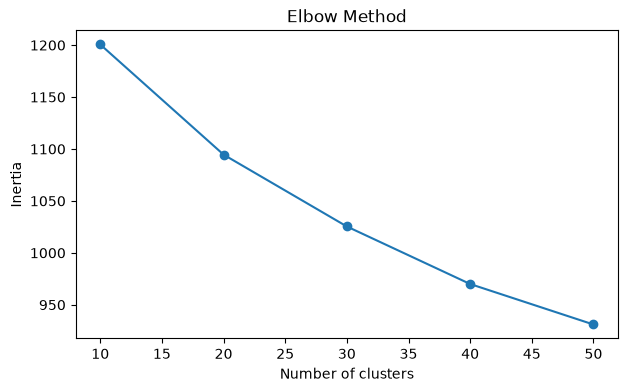

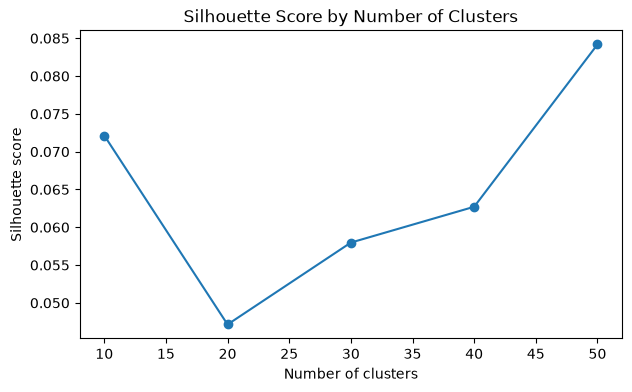

In [39]:
plt.figure(figsize=(7, 4))
plt.plot(
    cluster_diagnostics["k"],
    cluster_diagnostics["inertia"],
    marker="o"
)
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(
    cluster_diagnostics["k"],
    cluster_diagnostics["silhouette_score"],
    marker="o"
)
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.title("Silhouette Score by Number of Clusters")
plt.show()

### Interpretation

Among the tested values, k=50 produced the highest silhouette score (~0.084). The scores remain relatively low overall, indicating overlapping semantic structure. Since clustering is exploratory rather than the final classifier, k=50 is retained as a practical exploratory solution.

In [40]:
SELECTED_K = 50

kmeans = KMeans(
    n_clusters=SELECTED_K,
    random_state=42,
    n_init=10
)

cluster_vocabulary["cluster"] = kmeans.fit_predict(
    cluster_embeddings
)

cluster_vocabulary.head()

,skill,job_frequency,cluster
6217,Omsorg,1471,37
4801,Kundeservice,1396,25
3267,Helse,1106,41
1269,Butikk,1057,0
7597,Salg,981,0


## 6. Inspect the semantic clusters

The purpose of clustering is to discover broad structures in the vocabulary.

It is **not** used to say that every skill in a cluster belongs to the same final future-skill category.

In [41]:
cluster_summary = (
    cluster_vocabulary
    .sort_values(
        ["cluster", "job_frequency"],
        ascending=[True, False]
    )
    .groupby("cluster")
    .head(10)
)

for cluster_id in sorted(cluster_summary["cluster"].unique()):
    skills = (
        cluster_summary.loc[
            cluster_summary["cluster"] == cluster_id,
            "skill"
        ]
        .tolist()
    )

    print(f"CLUSTER {cluster_id}")
    print(", ".join(skills))
    print()

CLUSTER 0
Butikk, Salg, Butikkmedarbeider, Kundebehandling, Butikkselger, Innkjøp, Butikkleder, Detaljhandel, Butikksjef, Markedsføring

CLUSTER 1
Barnehage, Matlaging, Akuttmedisin, Rydding, Primærkontakt, Allmennmedisin, Tekstil, Håndverk, Optikk, Hårklipp

CLUSTER 2
Strategi, Installasjon, Python, Systemutvikling, Programmering, Prosessforbedring, Systemutvikler, Programmerer, Teknisk forståelse, Teknisk support

CLUSTER 3
Dokumentasjon, Rapportering, Arkiv, Sosiale medier, Journalføring, Fakturering, Bibliotek, Journalsystem, Dokumentforvaltning, Video

CLUSTER 4
Hjemmetjeneste, Bolig, Husarbeid, Hjemmehjelp, Eiendom, Eiendomsforvaltning, Hjemmebasert omsorg, hjemmetjeneste, Hjemmekontor, Møbler

CLUSTER 5
Rådgiver, Pasientbehandling, Saksbehandling, Sykehjem, Rådgivning, Praktisk bistand, Ekstrahjelp, Behandling, Gjestebehandling, omsorg

CLUSTER 6
Ingeniør, Teknologi, Håndverker, Teknisk drift, Teknisk dokumentasjon, Tekniker, Prosjektingeniør, Teknisk arbeid, Teknisk tegning, Se

### What the clustering taught us

The exploratory clusters successfully reveal broad semantic areas such as data, software, healthcare, engineering, administration, and digitalization.

However, some clusters also mix relevant and irrelevant concepts.

For example, a technology-oriented cluster may also contain mechanical or operational skills, while an analysis-oriented cluster may contain unrelated support roles.

### Why this happens

KMeans must assign **every observation** to one cluster. It does not have a concept of:

> "This skill does not belong to the AI/digital domain."

Therefore:

**We keep clustering as exploratory evidence, but we do not use whole clusters as the final AI/digital classification.**

This avoids conclusions such as:

- assigning BPA to "Analysis & Reporting"
- assigning a mechanic skill to "AI & Software"
- treating a whole mixed cluster as a future-skill domain

# Part B — Final digital-skill classification with ESCO

## 7. Why use ESCO?

For the final classification, we need an external reference that is:

- designed for labor-market analysis
- multilingual
- based on standardized skill concepts
- able to distinguish digital skills without a manually written keyword list

ESCO (European Skills, Competences, Qualifications and Occupations) provides:

- a multilingual European skill taxonomy
- unique concept URIs
- Norwegian and English labels
- an official `digitalSkillsCollection`

### Key methodological change

We will map **all observed NAV skills** to **all ESCO skill concepts**.

Only after finding the best ESCO concept do we ask whether that ESCO concept has the official digital label.

This is important.

If we matched NAV skills only against digital ESCO skills, a non-digital skill would be forced to match *some* digital skill.  
By matching against **all ESCO skills first**, unrelated skills can map to non-digital ESCO concepts and remain excluded.

Official sources:

- https://esco.ec.europa.eu/en/use-esco/download
- https://esco.ec.europa.eu/en/about-esco/escopedia/escopedia/digital-skills-labelling-esco

## 8. Download and place ESCO data

Download the latest ESCO classification in **CSV** format for:

- Norwegian (`no`)
- English (`en`)

Extract the files somewhere under:

`data/external/esco/`

The downloaded package should contain files whose names begin with:

- `skills_`
- `digitalSkillsCollection_`

The code below searches subfolders automatically, so the exact extraction folder name is not important.

In [42]:
from pathlib import Path

ESCO_ROOT = Path("../data/external/esco").resolve()

print("ESCO folder:", ESCO_ROOT)
print("Exists:", ESCO_ROOT.exists())

csv_files = list(ESCO_ROOT.rglob("*.csv"))

print("CSV files found:", len(csv_files))

for file in csv_files:
    print(file.relative_to(ESCO_ROOT))

ESCO folder: E:\@UIO\Python\Norway-future-skills\data\external\esco
Exists: True
CSV files found: 37
norwegian\v1.2.1\broaderRelationsOccPillar_no.csv
norwegian\v1.2.1\broaderRelationsSkillPillar_no.csv
norwegian\v1.2.1\dictionary_no.csv
norwegian\v1.2.1\digCompSkillsCollection_no.csv
norwegian\v1.2.1\digitalSkillsCollection_no.csv
norwegian\v1.2.1\greenShareOcc_no.csv
norwegian\v1.2.1\greenSkillsCollection_no.csv
norwegian\v1.2.1\ISCOGroups_no.csv
norwegian\v1.2.1\languageSkillsCollection_no.csv
norwegian\v1.2.1\occupationSkillRelations_no.csv
norwegian\v1.2.1\occupations_no.csv
norwegian\v1.2.1\researchOccupationsCollection_no.csv
norwegian\v1.2.1\researchSkillsCollection_no.csv
norwegian\v1.2.1\skillGroups_no.csv
norwegian\v1.2.1\skillsHierarchy_no.csv
norwegian\v1.2.1\skillSkillRelations_no.csv
norwegian\v1.2.1\skills_no.csv
norwegian\v1.2.1\transversalSkillsCollection_no.csv
english\v1.2.1\broaderRelationsOccPillar_en.csv
english\v1.2.1\broaderRelationsSkillPillar_en.csv
english\v

In [43]:
from pathlib import Path

ESCO_ROOT = Path("../data/external/esco").resolve()

def find_esco_file(filename):
    matches = list(ESCO_ROOT.rglob(filename))

    if len(matches) == 0:
        raise FileNotFoundError(
            f"Could not find {filename} under {ESCO_ROOT}"
        )

    if len(matches) > 1:
        print(f"Warning: multiple files found for {filename}")
        for file in matches:
            print(file)

    return matches[0]


skills_no_path = find_esco_file("skills_no.csv")
skills_en_path = find_esco_file("skills_en.csv")

digital_no_path = find_esco_file(
    "digitalSkillsCollection_no.csv"
)

digital_en_path = find_esco_file(
    "digitalSkillsCollection_en.csv"
)


print("Norwegian skills:")
print(skills_no_path)

print("\nEnglish skills:")
print(skills_en_path)

print("\nNorwegian digital skills:")
print(digital_no_path)

print("\nEnglish digital skills:")
print(digital_en_path)

Norwegian skills:
E:\@UIO\Python\Norway-future-skills\data\external\esco\norwegian\v1.2.1\skills_no.csv

English skills:
E:\@UIO\Python\Norway-future-skills\data\external\esco\english\v1.2.1\skills_en.csv

Norwegian digital skills:
E:\@UIO\Python\Norway-future-skills\data\external\esco\norwegian\v1.2.1\digitalSkillsCollection_no.csv

English digital skills:
E:\@UIO\Python\Norway-future-skills\data\external\esco\english\v1.2.1\digitalSkillsCollection_en.csv


## 9. Load ESCO skills and the official digital collection

ESCO files can change slightly between releases, so the helper functions below detect the URI and label columns instead of assuming one exact column layout.

In [44]:
def read_esco_csv(path):
    try:
        return pd.read_csv(
            path,
            encoding="utf-8-sig"
        )
    except Exception:
        return pd.read_csv(
            path,
            encoding="utf-8-sig",
            sep=None,
            engine="python"
        )

esco_skills_no = read_esco_csv(skills_no_path)
esco_skills_en = read_esco_csv(skills_en_path)

esco_digital_no = read_esco_csv(digital_no_path)
esco_digital_en = read_esco_csv(digital_en_path)

print("Norwegian skills:", esco_skills_no.shape)
print("English skills:", esco_skills_en.shape)
print("Norwegian digital collection:", esco_digital_no.shape)
print("English digital collection:", esco_digital_en.shape)

Norwegian skills: (13960, 13)
English skills: (13960, 13)
Norwegian digital collection: (1284, 10)
English digital collection: (1284, 10)


In [45]:
def detect_column(df, candidates, required=True):
    lookup = {
        str(col).strip().lower(): col
        for col in df.columns
    }

    for candidate in candidates:
        key = candidate.lower()
        if key in lookup:
            return lookup[key]

    if required:
        raise KeyError(
            f"None of {candidates} found. "
            f"Available columns: {list(df.columns)}"
        )

    return None

def prepare_esco_language(skills_df, language):
    uri_col = detect_column(
        skills_df,
        ["conceptUri", "conceptURI", "uri"]
    )

    label_col = detect_column(
        skills_df,
        ["preferredLabel", "preferredTerm", "label"]
    )

    result = skills_df[
        [uri_col, label_col]
    ].copy()

    result.columns = [
        "esco_uri",
        "esco_label"
    ]

    result["language"] = language

    return result.dropna().drop_duplicates()

esco_labels = pd.concat(
    [
        prepare_esco_language(
            esco_skills_no,
            "no"
        ),
        prepare_esco_language(
            esco_skills_en,
            "en"
        )
    ],
    ignore_index=True
).drop_duplicates()

esco_labels.head()

,esco_uri,esco_label,language
0,http://data.europa.eu/esco/skill/0005c151-5b5a...,administrere musikkpersonell,no
1,http://data.europa.eu/esco/skill/00064735-8fad...,overvåke fengselsprosedyrer,no
2,http://data.europa.eu/esco/skill/000709ed-2be5...,anvende undertrykkelsesmotvirkende praksis,no
3,http://data.europa.eu/esco/skill/0007bdc2-dd15...,kontrollere samsvar med forskrifter for jernba...,no
4,http://data.europa.eu/esco/skill/00090cc1-1f27...,identifisere tilgjengelige tjenester,no


In [46]:
def get_uri_set(collection_df):
    uri_col = detect_column(
        collection_df,
        ["conceptUri", "conceptURI", "uri"]
    )

    return set(
        collection_df[uri_col]
        .dropna()
        .astype(str)
    )

digital_uris = (
    get_uri_set(esco_digital_no)
    | get_uri_set(esco_digital_en)
)

esco_labels["is_digital_esco"] = (
    esco_labels["esco_uri"]
    .astype(str)
    .isin(digital_uris)
)

print(
    "ESCO concepts labelled digital:",
    esco_labels.loc[
        esco_labels["is_digital_esco"],
        "esco_uri"
    ].nunique()
)

ESCO concepts labelled digital: 1284


The number of officially labelled digital skills depends on the ESCO release. In ESCO v1.2.1 used in this analysis, 1,284 unique concepts are included in the digital skills collection.

In [47]:
print(esco_skills_no.columns.tolist())

['conceptType', 'conceptUri', 'skillType', 'reuseLevel', 'preferredLabel', 'altLabels', 'hiddenLabels', 'status', 'modifiedDate', 'scopeNote', 'definition', 'inScheme', 'description']


In [48]:
esco_skills_no.head(2)

,conceptType,conceptUri,skillType,reuseLevel,preferredLabel,altLabels,hiddenLabels,status,modifiedDate,scopeNote,definition,inScheme,description
0,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/0005c151-5b5a...,skill/competence,sector-specific,administrere musikkpersonell,NaN,NaN,released,2023-11-30T15:53:37.136Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/skil...,Tildele og administrere personaloppgaver på om...
1,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/00064735-8fad...,skill/competence,occupation-specific,overvåke fengselsprosedyrer,NaN,NaN,released,2023-11-30T15:04:00.689Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/skil...,Føre tilsyn med driften av fengsler eller andr...


### Interpretation

The ESCO digital label is now attached through the **concept URI**, not through our own keywords.

The next task is to map each observed NAV skill to its closest ESCO concept.

## 10. Match NAV skills to ESCO concepts

The matching process has three stages:

1. **Exact matching**  
   NAV skills are compared with ESCO preferred and alternative labels in Norwegian and English. An exact match is accepted only when the normalized label points to one unique ESCO concept.

2. **Candidate retrieval for unmatched skills**  
   Skills without an unambiguous exact match are enriched with actual NAV job context:
   - common job titles
   - common job categories

   A multilingual Sentence Transformer retrieves a small set of candidate ESCO concepts.

3. **Context-aware reranking**  
   A CrossEncoder evaluates the NAV skill together with its labor-market context against richer ESCO concept documents.

This replaces the earlier short-string semantic approach that produced false matches such as unrelated words being mapped to software/product names.

Methodological references:
- Sentence Transformers retrieve-and-rerank: `https://www.sbert.net/examples/sentence_transformer/applications/retrieve_rerank/README.html`
- ESCO downloadable datasets: `https://esco.ec.europa.eu/en/structure-esco-downloadable-datasets`

### 10.1 Build ESCO preferred + alternative label reference

In [49]:
import re
import ast
import unicodedata


def normalize_label(text):
    """Normalize text conservatively for exact matching."""
    if pd.isna(text):
        return ""

    text = unicodedata.normalize("NFKC", str(text))
    text = text.casefold().strip()
    text = re.sub(r"\s+", " ", text)

    return text


def split_alt_labels(value):
    """
    Convert ESCO altLabels into individual labels.

    Handles missing values, list-like strings, newlines,
    semicolons and pipes. Commas are intentionally not used
    as separators because they may occur inside valid labels.
    """
    if pd.isna(value):
        return []

    if isinstance(value, (list, tuple, set)):
        return [
            str(x).strip()
            for x in value
            if str(x).strip()
        ]

    text = str(value).strip()

    if not text:
        return []

    try:
        parsed = ast.literal_eval(text)

        if isinstance(parsed, (list, tuple, set)):
            return [
                str(x).strip()
                for x in parsed
                if str(x).strip()
            ]
    except (ValueError, SyntaxError):
        pass

    text = text.replace("\\n", "\n")

    parts = re.split(
        r"\s*(?:\r?\n|;|\|)\s*",
        text
    )

    return [
        part.strip()
        for part in parts
        if part.strip()
    ]


def build_esco_label_reference(skills_df, language):
    records = []

    for _, row in skills_df.iterrows():
        uri = str(row["conceptUri"])

        preferred = row["preferredLabel"]

        if pd.notna(preferred):
            records.append({
                "esco_uri": uri,
                "esco_match_label": str(preferred).strip(),
                "label_type": "preferred",
                "language": language
            })

        for alt_label in split_alt_labels(row["altLabels"]):
            records.append({
                "esco_uri": uri,
                "esco_match_label": alt_label,
                "label_type": "alternative",
                "language": language
            })

    return pd.DataFrame(records)


esco_label_reference = pd.concat(
    [
        build_esco_label_reference(esco_skills_no, "no"),
        build_esco_label_reference(esco_skills_en, "en")
    ],
    ignore_index=True
)

esco_label_reference["label_normalized"] = (
    esco_label_reference["esco_match_label"]
    .apply(normalize_label)
)

esco_label_reference["is_digital_esco"] = (
    esco_label_reference["esco_uri"]
    .astype(str)
    .isin(digital_uris)
)

esco_label_reference = (
    esco_label_reference
    .drop_duplicates(
        subset=[
            "esco_uri",
            "label_normalized",
            "language"
        ]
    )
    .reset_index(drop=True)
)

print("ESCO searchable labels:", len(esco_label_reference))
print(
    "Unique ESCO concepts:",
    esco_label_reference["esco_uri"].nunique()
)
print(
    "Digital ESCO concepts:",
    esco_label_reference.loc[
        esco_label_reference["is_digital_esco"],
        "esco_uri"
    ].nunique()
)

ESCO searchable labels: 119180
Unique ESCO concepts: 13939
Digital ESCO concepts: 1284


### 10.2 Exact matching first

Exact matches are accepted only when the same normalized label maps to one unique ESCO URI.

If the same exact label can refer to several ESCO concepts, it is treated as ambiguous and passed to the context-aware stage.

In [50]:
nav_skill_reference = (
    skills_jobs_df
    .groupby("skill")
    .agg(
        job_frequency=("job_id", "nunique")
    )
    .reset_index()
)

nav_skill_reference["skill_normalized"] = (
    nav_skill_reference["skill"]
    .apply(normalize_label)
)

exact_candidates = (
    nav_skill_reference
    .merge(
        esco_label_reference,
        left_on="skill_normalized",
        right_on="label_normalized",
        how="inner"
    )
)

exact_uri_counts = (
    exact_candidates
    .groupby("skill")["esco_uri"]
    .nunique()
)

unambiguous_exact_skills = set(
    exact_uri_counts[
        exact_uri_counts == 1
    ].index
)

ambiguous_exact_skills = set(
    exact_uri_counts[
        exact_uri_counts > 1
    ].index
)

exact_matches = (
    exact_candidates[
        exact_candidates["skill"].isin(
            unambiguous_exact_skills
        )
    ]
    .assign(
        label_priority=lambda x:
        x["label_type"].map({
            "preferred": 0,
            "alternative": 1
        })
    )
    .sort_values(
        ["skill", "label_priority"]
    )
    .drop_duplicates(
        subset="skill"
    )
)

exact_matches = (
    exact_matches[
        [
            "skill",
            "job_frequency",
            "esco_uri",
            "esco_match_label",
            "language",
            "is_digital_esco"
        ]
    ]
    .rename(
        columns={
            "esco_match_label": "esco_label",
            "language": "esco_language"
        }
    )
    .copy()
)

exact_matches["match_method"] = "exact"
exact_matches["retrieval_score"] = np.nan
exact_matches["rerank_score"] = 1.0
exact_matches["rerank_margin"] = np.nan

print("NAV skills:", len(nav_skill_reference))
print("Unambiguous exact matches:", len(exact_matches))
print("Ambiguous exact labels:", len(ambiguous_exact_skills))
print(
    "Remaining for context-aware matching:",
    len(nav_skill_reference) - len(exact_matches)
)

NAV skills: 10997
Unambiguous exact matches: 456
Ambiguous exact labels: 12
Remaining for context-aware matching: 10541


### 10.3 Build NAV skill context from actual job postings

The source `occupation` field is intentionally not used because earlier data-quality analysis showed that it is unavailable/unreliable for most postings.

Instead, every skill is enriched with representative job titles and categories.

In [51]:
def representative_values(
    series,
    n=5,
    max_chars=140
):
    """Return the most common meaningful values for a skill."""
    values = (
        series
        .dropna()
        .astype(str)
        .str.strip()
    )

    values = values[
        ~values.str.lower().eq("not classified")
    ]

    top_values = (
        values
        .value_counts()
        .head(n)
        .index
        .tolist()
    )

    return [
        value[:max_chars]
        for value in top_values
    ]


skill_context = (
    skills_jobs_df
    .groupby("skill")
    .agg(
        example_titles=(
            "title",
            lambda s: representative_values(
                s,
                n=3,
                max_chars=140
            )
        ),
        example_categories=(
            "category",
            lambda s: representative_values(
                s,
                n=5,
                max_chars=140
            )
        )
    )
    .reset_index()
)


def build_nav_context(row):
    titles = " | ".join(row["example_titles"])
    categories = " | ".join(row["example_categories"])

    parts = [f"Skill: {row['skill']}"]

    if titles:
        parts.append(
            f"Common job titles: {titles}"
        )

    if categories:
        parts.append(
            f"Common job categories: {categories}"
        )

    return ". ".join(parts)


skill_context["nav_context"] = (
    skill_context.apply(
        build_nav_context,
        axis=1
    )
)

skill_context.head()

,skill,example_titles,example_categories,nav_context
0,.NET,[Senior utvikler -- påvirk arkitektur og tekno...,"[Systemutvikler, Systemutvikler, Systemanalyti...",Skill: .NET. Common job titles: Senior utvikle...
1,.Net,[Vi søker erfaren .Net fullstackutvikler],"[.Net Utvikler, .Net Utvikler, Applikasjonspro...",Skill: .Net. Common job titles: Vi søker erfar...
2,.net,[Ønsker du å bli en del av et av Norges størst...,"[Full-stack-utvikler, Full-stack-utvikler, Pro...",Skill: .net. Common job titles: Ønsker du å bl...
3,110-sentral,[Samfunnsvitar til arbeidet med nytt naudnett ...,"[Andre ingeniører, Sikkerhetsrådgiver (helse, ...",Skill: 110-sentral. Common job titles: Samfunn...
4,12V,"[Har du mekanisk sans, båtinteresse og kontrol...","[Anleggsmaskin- og industrimekanikere, Bilmeka...",Skill: 12V. Common job titles: Har du mekanisk...


### 10.4 Build one richer document per ESCO concept

Each ESCO concept document combines available Norwegian/English preferred labels, alternative labels, descriptions, and definitions.

This reduces reliance on short-string similarity.

In [52]:
def compact_alt_labels(value, limit=8):
    labels = split_alt_labels(value)
    return "; ".join(labels[:limit])


def clean_optional_text(value, max_chars=500):
    if pd.isna(value):
        return ""

    text = re.sub(
        r"\s+",
        " ",
        str(value).strip()
    )

    return text[:max_chars]


def prepare_esco_concepts(skills_df, language):
    cols = [
        "conceptUri",
        "preferredLabel",
        "altLabels",
        "description",
        "definition"
    ]

    result = skills_df[cols].copy()

    result = result.rename(
        columns={
            "conceptUri": "esco_uri",
            "preferredLabel": f"preferred_{language}",
            "altLabels": f"alt_{language}",
            "description": f"description_{language}",
            "definition": f"definition_{language}"
        }
    )

    result["esco_uri"] = result[
        "esco_uri"
    ].astype(str)

    return result.drop_duplicates(
        subset="esco_uri"
    )


esco_concepts_no = prepare_esco_concepts(
    esco_skills_no,
    "no"
)

esco_concepts_en = prepare_esco_concepts(
    esco_skills_en,
    "en"
)

esco_concepts = (
    esco_concepts_no
    .merge(
        esco_concepts_en,
        on="esco_uri",
        how="outer"
    )
)

esco_concepts["is_digital_esco"] = (
    esco_concepts["esco_uri"]
    .isin(digital_uris)
)


def build_esco_document(row):
    parts = []

    preferred_no = clean_optional_text(
        row.get("preferred_no"),
        220
    )
    preferred_en = clean_optional_text(
        row.get("preferred_en"),
        220
    )

    if preferred_no:
        parts.append(
            f"Norwegian skill: {preferred_no}"
        )

    if preferred_en:
        parts.append(
            f"English skill: {preferred_en}"
        )

    alt_no = compact_alt_labels(
        row.get("alt_no"),
        limit=8
    )
    alt_en = compact_alt_labels(
        row.get("alt_en"),
        limit=8
    )

    if alt_no:
        parts.append(
            f"Norwegian alternative labels: {alt_no}"
        )

    if alt_en:
        parts.append(
            f"English alternative labels: {alt_en}"
        )

    description_no = clean_optional_text(
        row.get("description_no"),
        500
    )
    description_en = clean_optional_text(
        row.get("description_en"),
        500
    )

    definition_no = clean_optional_text(
        row.get("definition_no"),
        350
    )
    definition_en = clean_optional_text(
        row.get("definition_en"),
        350
    )

    if description_no:
        parts.append(
            f"Norwegian description: {description_no}"
        )

    if description_en:
        parts.append(
            f"English description: {description_en}"
        )

    if definition_no:
        parts.append(
            f"Norwegian definition: {definition_no}"
        )

    if definition_en:
        parts.append(
            f"English definition: {definition_en}"
        )

    return ". ".join(parts)


esco_concepts["esco_document"] = (
    esco_concepts.apply(
        build_esco_document,
        axis=1
    )
)

print(
    "ESCO concept documents:",
    esco_concepts["esco_uri"].nunique()
)

esco_concepts[
    [
        "esco_uri",
        "preferred_no",
        "preferred_en",
        "is_digital_esco",
        "esco_document"
    ]
].head()

ESCO concept documents: 13939


,esco_uri,preferred_no,preferred_en,is_digital_esco,esco_document
0,http://data.europa.eu/esco/skill/0005c151-5b5a...,administrere musikkpersonell,manage musical staff,False,Norwegian skill: administrere musikkpersonell....
1,http://data.europa.eu/esco/skill/00064735-8fad...,overvåke fengselsprosedyrer,supervise correctional procedures,False,Norwegian skill: overvåke fengselsprosedyrer. ...
2,http://data.europa.eu/esco/skill/000709ed-2be5...,anvende undertrykkelsesmotvirkende praksis,apply anti-oppressive practices,False,Norwegian skill: anvende undertrykkelsesmotvir...
3,http://data.europa.eu/esco/skill/0007bdc2-dd15...,kontrollere samsvar med forskrifter for jernba...,control compliance of railway vehicles regulat...,False,Norwegian skill: kontrollere samsvar med forsk...
4,http://data.europa.eu/esco/skill/00090cc1-1f27...,identifisere tilgjengelige tjenester,identify available services,False,Norwegian skill: identifisere tilgjengelige tj...


### 10.5 Retrieve candidate ESCO concepts

Only unmatched/ambiguous NAV skills enter this stage.

A multilingual bi-encoder retrieves a small candidate set from all ESCO concepts. Retrieval is only the first stage; the next cell reranks those candidates jointly with the NAV job context.

In [55]:
from sentence_transformers import util

exact_matched_skills = set(
    exact_matches["skill"]
)

semantic_nav_skills = (
    nav_skill_reference[
        ~nav_skill_reference["skill"].isin(
            exact_matched_skills
        )
    ]
    .merge(
        skill_context[
            ["skill", "nav_context"]
        ],
        on="skill",
        how="left"
    )
    .reset_index(drop=True)
)

print(
    "Skills requiring context-aware matching:",
    len(semantic_nav_skills)
)

TOP_K = 20

nav_context_embeddings = (
    embedding_model.encode(
        semantic_nav_skills[
            "nav_context"
        ].tolist(),
        show_progress_bar=True,
        normalize_embeddings=True
    )
)

esco_concept_embeddings = (
    embedding_model.encode(
        esco_concepts[
            "esco_document"
        ].tolist(),
        show_progress_bar=True,
        normalize_embeddings=True
    )
)

retrieval_hits = util.semantic_search(
    nav_context_embeddings,
    esco_concept_embeddings,
    top_k=TOP_K
)

print(
    f"Retrieved up to {TOP_K} ESCO candidates "
    "for each unmatched NAV skill."
)

Skills requiring context-aware matching: 10541


Batches:   0%|          | 0/330 [00:00<?, ?it/s]

Batches:   0%|          | 0/436 [00:00<?, ?it/s]

Retrieved up to 20 ESCO candidates for each unmatched NAV skill.


### 10.6 Context-aware reranking

The reranker receives the NAV skill **with its titles/categories** and one retrieved ESCO concept document at the same time.

This follows a standard retrieve-and-rerank architecture.

The first run downloads the reranker model. Reranker scores are relevance signals, not automatically calibrated probabilities, so Section 11 still validates them.

Model used: `cross-encoder/mmarco-mMiniLMv2-L12-H384-v1`.

In [56]:
from sentence_transformers import CrossEncoder
import torch
import numpy as np
import pandas as pd


# ---------------------------------------------------------
# 1. Load reranker
# ---------------------------------------------------------

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Reranker device:", DEVICE)

reranker = CrossEncoder(
    "cross-encoder/mmarco-mMiniLMv2-L12-H384-v1",
    device=DEVICE,
    max_length=256,
    activation_fn=torch.nn.Sigmoid()
)


# ---------------------------------------------------------
# 2. Build a SMALL shortlist
# ---------------------------------------------------------
#
# Our goal is digital vs non-digital classification.
#
# Therefore, for each NAV skill we only need the strongest:
#
#   1. digital ESCO candidate
#   2. non-digital ESCO candidate
#
# We do NOT need to rerank all 20 retrieved concepts.
#
# If no digital concept appears in the top-20 retrieval
# results, the skill is provisionally screened as
# non-digital and does not need expensive reranking.
# ---------------------------------------------------------

candidate_records = []
rerank_pairs = []
rerank_row_indices = []

screened_non_digital = 0
skills_sent_to_reranker = 0


for nav_index, hits in enumerate(retrieval_hits):

    nav_row = semantic_nav_skills.iloc[nav_index]

    query_text = nav_row["nav_context"]

    candidates = []

    # Build candidate information from retrieval results
    for hit in hits:

        corpus_id = hit["corpus_id"]

        esco_row = esco_concepts.iloc[
            corpus_id
        ]

        candidates.append({

            "nav_index": nav_index,

            "skill":
                nav_row["skill"],

            "job_frequency":
                nav_row["job_frequency"],

            "esco_index":
                corpus_id,

            "esco_uri":
                esco_row["esco_uri"],

            "esco_label_no":
                esco_row["preferred_no"],

            "esco_label_en":
                esco_row["preferred_en"],

            "is_digital_esco":
                bool(
                    esco_row[
                        "is_digital_esco"
                    ]
                ),

            "retrieval_score":
                float(hit["score"]),

            "esco_document":
                esco_row["esco_document"]
        })


    # Candidates are already ordered by retrieval score
    digital_candidates = [
        candidate
        for candidate in candidates
        if candidate["is_digital_esco"]
    ]

    non_digital_candidates = [
        candidate
        for candidate in candidates
        if not candidate["is_digital_esco"]
    ]


    # -----------------------------------------------------
    # CASE 1:
    # No digital concept among top retrieval candidates
    #
    # Keep the strongest non-digital concept for reference,
    # but do NOT waste CrossEncoder computation on it.
    # -----------------------------------------------------

    if len(digital_candidates) == 0:

        best_candidate = candidates[0].copy()

        best_candidate[
            "was_reranked"
        ] = False

        candidate_records.append(
            best_candidate
        )

        screened_non_digital += 1

        continue


    # -----------------------------------------------------
    # CASE 2:
    # Digital concept is plausible.
    #
    # Let CrossEncoder compare:
    #
    # best digital candidate
    #        VS
    # best non-digital candidate
    # -----------------------------------------------------

    shortlist = []

    # strongest digital candidate
    shortlist.append(
        digital_candidates[0]
    )

    # strongest competing non-digital candidate
    if len(non_digital_candidates) > 0:

        shortlist.append(
            non_digital_candidates[0]
        )


    skills_sent_to_reranker += 1


    for candidate in shortlist:

        candidate = candidate.copy()

        candidate[
            "was_reranked"
        ] = True

        # Position this row will have in candidate_matches
        row_index = len(
            candidate_records
        )

        candidate_records.append(
            candidate
        )

        rerank_row_indices.append(
            row_index
        )

        rerank_pairs.append(
            (
                query_text,
                candidate[
                    "esco_document"
                ]
            )
        )


# ---------------------------------------------------------
# 3. Convert candidate records to DataFrame
# ---------------------------------------------------------

candidate_matches = pd.DataFrame(
    candidate_records
)

candidate_matches[
    "rerank_score"
] = np.nan


# ---------------------------------------------------------
# 4. Run CrossEncoder ONLY on shortlisted pairs
# ---------------------------------------------------------

print(
    "Total unmatched NAV skills:",
    len(semantic_nav_skills)
)

print(
    "Screened as non-digital without reranking:",
    screened_non_digital
)

print(
    "Skills sent to CrossEncoder:",
    skills_sent_to_reranker
)

print(
    "Candidate pairs to rerank:",
    len(rerank_pairs)
)


if len(rerank_pairs) > 0:

    # Larger batches work well on a GPU.
    # Keep CPU batches conservative.
    BATCH_SIZE = (
        128
        if DEVICE == "cuda"
        else 32
    )

    rerank_scores = reranker.predict(
        rerank_pairs,
        batch_size=BATCH_SIZE,
        show_progress_bar=True
    )

    rerank_scores = (
        np.asarray(
            rerank_scores
        )
        .reshape(-1)
    )

    candidate_matches.loc[
        rerank_row_indices,
        "rerank_score"
    ] = rerank_scores


# We no longer need the long ESCO document
# inside this intermediate result.
candidate_matches = (
    candidate_matches
    .drop(
        columns="esco_document",
        errors="ignore"
    )
)


candidate_matches.head()

Reranker device: cpu


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Total unmatched NAV skills: 10541
Screened as non-digital without reranking: 4278
Skills sent to CrossEncoder: 6263
Candidate pairs to rerank: 12485


Batches:   0%|          | 0/391 [00:00<?, ?it/s]

,nav_index,skill,job_frequency,esco_index,esco_uri,esco_label_no,esco_label_en,is_digital_esco,retrieval_score,was_reranked,rerank_score
0,0,110-sentral,2,3422,http://data.europa.eu/esco/skill/3e61ee41-2bd9...,lede selskapsavdelingsledere,lead managers of company departments,False,0.608227,False,NaN
1,1,12V,1,2591,http://data.europa.eu/esco/skill/2ee670aa-c687...,fartøymekanikk,mechanics of vessels,False,0.586779,False,NaN
2,2,2. linje brukerstøtte,1,10346,http://data.europa.eu/esco/skill/bec4359e-cb92...,Metoder innen IKT-prosjektledelse,ICT project management methodologies,True,0.551693,True,0.003107
3,2,2. linje brukerstøtte,1,3422,http://data.europa.eu/esco/skill/3e61ee41-2bd9...,lede selskapsavdelingsledere,lead managers of company departments,False,0.532610,True,0.008224
4,3,2. linje support,1,11,http://data.europa.eu/esco/skill/00298d97-3dc3...,lede politietterforskning,lead police investigations,False,0.560212,False,NaN


### 10.7 Select the best reranked ESCO concept

For each unmatched NAV skill:

- the highest `rerank_score` becomes the selected ESCO concept
- `rerank_margin` is the difference between the best and second-best candidate

A larger margin indicates clearer separation within the retrieved candidate set.

In [68]:
# ---------------------------------------------------------
# 10.7 Select final semantic candidate using
# retrieval + reranker agreement
# ---------------------------------------------------------

# A) Skills screened as non-digital during retrieval
screened_matches = (
    candidate_matches[
        ~candidate_matches["was_reranked"]
    ]
    .copy()
)

screened_matches["esco_label"] = (
    screened_matches["esco_label_no"]
    .fillna(screened_matches["esco_label_en"])
)

screened_matches["esco_language"] = np.where(
    screened_matches["esco_label_no"].notna(),
    "no",
    "en"
)

screened_matches["rerank_margin"] = np.nan
screened_matches["retrieval_margin"] = np.nan

screened_matches["match_method"] = (
    "retrieval_screen_non_digital"
)


# ---------------------------------------------------------
# B) Skills that had digital + non-digital competition
# ---------------------------------------------------------

reranked = (
    candidate_matches[
        candidate_matches["was_reranked"]
    ]
    .copy()
)


# Digital candidate
digital_candidate = (
    reranked[
        reranked["is_digital_esco"]
    ]
    .sort_values(
        ["nav_index", "rerank_score"],
        ascending=[True, False]
    )
    .drop_duplicates("nav_index")
)


# Non-digital candidate
non_digital_candidate = (
    reranked[
        ~reranked["is_digital_esco"]
    ]
    .sort_values(
        ["nav_index", "rerank_score"],
        ascending=[True, False]
    )
    .drop_duplicates("nav_index")
)


# ---------------------------------------------------------
# Compare digital vs non-digital directly
# ---------------------------------------------------------

comparison = digital_candidate.merge(
    non_digital_candidate,
    on="nav_index",
    suffixes=("_digital", "_non_digital"),
    how="inner"
)


comparison["retrieval_margin"] = (
    comparison["retrieval_score_digital"]
    - comparison["retrieval_score_non_digital"]
)


comparison["rerank_margin"] = (
    comparison["rerank_score_digital"]
    - comparison["rerank_score_non_digital"]
)


# Both models must agree that digital is better
comparison["digital_consensus"] = (
    (comparison["retrieval_margin"] > 0)
    &
    (comparison["rerank_margin"] > 0)
)


comparison[
    [
        "skill_digital",
        "job_frequency_digital",
        "esco_label_no_digital",
        "esco_label_no_non_digital",
        "retrieval_score_digital",
        "retrieval_score_non_digital",
        "rerank_score_digital",
        "rerank_score_non_digital",
        "retrieval_margin",
        "rerank_margin",
        "digital_consensus"
    ]
].head(20)

,skill_digital,job_frequency_digital,esco_label_no_digital,esco_label_no_non_digital,retrieval_score_digital,retrieval_score_non_digital,rerank_score_digital,rerank_score_non_digital,retrieval_margin,rerank_margin,digital_consensus
0,2. linje brukerstøtte,1,Metoder innen IKT-prosjektledelse,lede selskapsavdelingsledere,0.551693,0.532610,0.003107,0.008224,0.019083,-0.005117,False
1,24SevenOffice,1,online jobbplattformer,posisjonere kjernearbeidsstykker,0.502350,0.568726,0.001210,0.006720,-0.066376,-0.005510,False
2,3. linje support,2,tjenesteorientert modellering,konstruere arbeidsplattform,0.512122,0.511742,0.002415,0.003746,0.000380,-0.001331,False
3,3D konstruksjon,1,design for maskinvaredeler og forbindelser,skinnekonstruksjonsteknikk,0.587360,0.598882,0.264108,0.107333,-0.011522,0.156775,False
4,3D modellering,1,3D-modellering,tolke 3D-planer,0.651703,0.576660,0.999067,0.727234,0.075043,0.271834,True
5,3D-design,2,utforme elektriske systemer,skinnekonstruksjonsteknikk,0.546364,0.571168,0.039682,0.025141,-0.024804,0.014541,False
6,3D-modellering,18,lage 3D CAD-fottøyprototyper,luftfartsteknologi,0.575212,0.595280,0.448246,0.002357,-0.020068,0.445889,False
7,3D-scanning,1,3D-modellering,strømlinjeformet produksjon,0.607382,0.589871,0.951320,0.000436,0.017511,0.950884,True
8,5S,1,dataprogrammering,5S-metodikk,0.514889,0.508024,0.002881,0.996411,0.006864,-0.993529,False
9,A-lis,1,dataprogrammering,kombinere flere kunnskapsfelt,0.548205,0.593336,0.998859,0.999233,-0.045131,-0.000374,False


In [69]:
semantic_records = []

for _, row in comparison.iterrows():

    # ---------------------------------------------
    # Digital only when BOTH stages prefer digital
    # ---------------------------------------------
    if row["digital_consensus"]:

        semantic_records.append({
            "skill":
                row["skill_digital"],

            "job_frequency":
                row["job_frequency_digital"],

            "esco_uri":
                row["esco_uri_digital"],

            "esco_label":
                (
                    row["esco_label_no_digital"]
                    if pd.notna(
                        row["esco_label_no_digital"]
                    )
                    else row["esco_label_en_digital"]
                ),

            "esco_language":
                (
                    "no"
                    if pd.notna(
                        row["esco_label_no_digital"]
                    )
                    else "en"
                ),

            "is_digital_esco":
                True,

            "retrieval_score":
                row["retrieval_score_digital"],

            "rerank_score":
                row["rerank_score_digital"],

            "retrieval_margin":
                row["retrieval_margin"],

            "rerank_margin":
                row["rerank_margin"],

            "match_method":
                "digital_consensus"
        })

    # ---------------------------------------------
    # Otherwise choose non-digital conservatively
    # ---------------------------------------------
    else:

        semantic_records.append({
            "skill":
                row["skill_non_digital"],

            "job_frequency":
                row["job_frequency_non_digital"],

            "esco_uri":
                row["esco_uri_non_digital"],

            "esco_label":
                (
                    row["esco_label_no_non_digital"]
                    if pd.notna(
                        row["esco_label_no_non_digital"]
                    )
                    else row["esco_label_en_non_digital"]
                ),

            "esco_language":
                (
                    "no"
                    if pd.notna(
                        row["esco_label_no_non_digital"]
                    )
                    else "en"
                ),

            "is_digital_esco":
                False,

            "retrieval_score":
                row["retrieval_score_non_digital"],

            "rerank_score":
                row["rerank_score_non_digital"],

            "retrieval_margin":
                row["retrieval_margin"],

            "rerank_margin":
                row["rerank_margin"],

            "match_method":
                "non_digital_disagreement"
        })


semantic_compared = pd.DataFrame(
    semantic_records
)


# Add skills screened earlier as clearly non-digital
screened_result = screened_matches[
    [
        "skill",
        "job_frequency",
        "esco_uri",
        "esco_label",
        "esco_language",
        "is_digital_esco",
        "retrieval_score",
        "rerank_score",
        "retrieval_margin",
        "rerank_margin",
        "match_method"
    ]
]


semantic_matches = pd.concat(
    [
        semantic_compared,
        screened_result
    ],
    ignore_index=True
)


print(
    semantic_matches[
        "match_method"
    ].value_counts()
)

match_method
non_digital_disagreement        5704
retrieval_screen_non_digital    4278
digital_consensus                518
Name: count, dtype: int64


### 10.8 Combine exact and context-aware matches

In [70]:
match_columns = [
    "skill",
    "job_frequency",
    "esco_uri",
    "esco_label",
    "esco_language",
    "is_digital_esco",
    "retrieval_score",
    "rerank_score",
    "rerank_margin",
    "match_method"
]

esco_matches = pd.concat(
    [
        exact_matches[match_columns],
        semantic_matches[match_columns]
    ],
    ignore_index=True
)

print(
    "Total NAV skills:",
    nav_skill_reference["skill"].nunique()
)

print(
    "Total mapped skills:",
    esco_matches["skill"].nunique()
)

print("\nMatch methods:")
print(
    esco_matches[
        "match_method"
    ].value_counts()
)

print(
    "\nCurrently mapped to digital ESCO concepts:",
    esco_matches.loc[
        esco_matches["is_digital_esco"],
        "skill"
    ].nunique()
)

Total NAV skills: 10997
Total mapped skills: 10956

Match methods:
match_method
non_digital_disagreement        5704
retrieval_screen_non_digital    4278
digital_consensus                518
exact                            456
Name: count, dtype: int64

Currently mapped to digital ESCO concepts: 636


### 10.9 Smoke-test the terms that exposed the earlier problem

These terms previously generated clearly unrelated semantic matches.

This is not a manual filtering rule. It is a diagnostic check of whether the improved method fixes the failure mode.

In [71]:
problem_skills = [
    "Omsorg",
    "Salg",
    "Leder",
    "Sikkerhet",
    "Servering",
    "BPA",
    "Teknologi",
    "Politi"
]

display(
    esco_matches[
        esco_matches["skill"].isin(
            problem_skills
        )
    ][
        [
            "skill",
            "job_frequency",
            "esco_label",
            "match_method",
            "is_digital_esco",
            "retrieval_score",
            "rerank_score",
            "rerank_margin"
        ]
    ]
    .sort_values("skill")
)

,skill,job_frequency,esco_label,match_method,is_digital_esco,retrieval_score,rerank_score,rerank_margin
6894,BPA,246,personalledelse,retrieval_screen_non_digital,False,0.505071,NaN,NaN
8636,Leder,895,lede selskapsavdelingsledere,retrieval_screen_non_digital,False,0.696943,NaN,NaN
9092,Omsorg,1471,prosesser ved personalressursavdelingen,retrieval_screen_non_digital,False,0.538242,NaN,NaN
9346,Politi,121,lede politietterforskning,retrieval_screen_non_digital,False,0.562338,NaN,NaN
9682,Salg,981,lede selskapsavdelingsledere,retrieval_screen_non_digital,False,0.478618,NaN,NaN
4858,Servering,262,arbeide på et matbehandlingsteam,non_digital_disagreement,False,0.593587,0.027278,-0.019451
4912,Sikkerhet,265,lede selskapsavdelingsledere,non_digital_disagreement,False,0.499950,0.344636,0.322542
5524,Teknologi,164,Metoder innen IKT-prosjektledelse,digital_consensus,True,0.562704,0.049665,0.029680


In [72]:
candidate_matches[
    candidate_matches["skill"].isin(
        ["Sikkerhet", "Teknologi"]
    )
][
    [
        "skill",
        "esco_label_no",
        "esco_label_en",
        "is_digital_esco",
        "retrieval_score",
        "rerank_score",
        "was_reranked"
    ]
].sort_values(
    ["skill", "rerank_score"],
    ascending=[True, False]
)

,skill,esco_label_no,esco_label_en,is_digital_esco,retrieval_score,rerank_score,was_reranked
12047,Sikkerhet,IKT-sikkerhetsstandarder,ICT security standards,True,0.478986,0.667178,True
12048,Sikkerhet,lede selskapsavdelingsledere,lead managers of company departments,False,0.499950,0.344636,True
13720,Teknologi,Metoder innen IKT-prosjektledelse,ICT project management methodologies,True,0.562704,0.049665,True
13721,Teknologi,prosjektledelse,project management,False,0.551643,0.019985,True


## 11. Validate digital-consensus matches

Exact ESCO matches are accepted directly because the normalized NAV label maps
unambiguously to one ESCO concept.

For unmatched skills, the classification is intentionally conservative:

- if no digital ESCO concept appears among the strongest retrieval candidates,
  the skill is screened as non-digital
- if retrieval and reranking disagree, the skill is not classified as digital
- only skills where both stages prefer the digital concept become
  `digital_consensus` candidates

However, agreement alone does not guarantee a strong match.

Therefore, the remaining digital-consensus candidates are evaluated using:

- retrieval score
- retrieval margin between digital and non-digital candidates
- reranker score
- reranker margin

Low-confidence consensus matches are removed before final labor-market analysis.

In [73]:
digital_consensus_check = esco_matches[
    esco_matches["match_method"] == "digital_consensus"
].copy()

print(
    "Digital-consensus candidates:",
    len(digital_consensus_check)
)

display(
    digital_consensus_check[
        [
            "skill",
            "job_frequency",
            "esco_label",
            "retrieval_score",
            "rerank_score",
            "rerank_margin"
        ]
    ]
    .sort_values(
        "job_frequency",
        ascending=False
    )
    .head(40)
)

Digital-consensus candidates: 518


,skill,job_frequency,esco_label,retrieval_score,rerank_score,rerank_margin
5524,Teknologi,164,Metoder innen IKT-prosjektledelse,0.562704,0.049665,0.029680
1572,ERP,110,transportprogramvare relatert til et ERP-system,0.552885,0.997211,0.970117
4341,Produktutvikling,79,håndtere geospatiale teknologier,0.650498,0.916909,0.013613
5453,Teknisk dokumentasjon,67,innhente trusseletterretning,0.595472,0.032917,0.023278
5368,Systemutvikling,66,dataprogrammering,0.604904,0.919450,0.198102
4363,Programmering,59,dataprogrammering,0.714441,0.918833,0.276105
475,AI,57,prinsipper for kunstig intelligens,0.558437,0.999609,0.001320
4018,Oppsøkende salg,47,søkemotoroptimalisering,0.527115,0.072195,0.005979
5367,Systemutvikler,43,dataprogrammering,0.654646,0.998863,0.002030
738,Automatiker,42,robotkomponenter,0.684346,0.983146,0.000696


In [74]:
print("Rerank score distribution:")

display(
    digital_consensus_check[
        "rerank_score"
    ].describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95
        ]
    )
)

print("\nRerank margin distribution:")

display(
    digital_consensus_check[
        "rerank_margin"
    ].describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95
        ]
    )
)

Rerank score distribution:


count    518.000000
mean       0.581680
std        0.417255
min        0.000462
10%        0.009395
25%        0.077790
50%        0.796669
75%        0.990756
90%        0.999140
95%        0.999695
max        0.999975
Name: rerank_score, dtype: float64


Rerank margin distribution:


count    518.000000
mean       0.182527
std        0.278379
min        0.000002
10%        0.000749
25%        0.005008
50%        0.037300
75%        0.230006
90%        0.719103
95%        0.873347
max        0.998691
Name: rerank_margin, dtype: float64

In [75]:
display(
    digital_consensus_check[
        [
            "skill",
            "job_frequency",
            "esco_label",
            "retrieval_score",
            "rerank_score",
            "rerank_margin"
        ]
    ]
    .sort_values(
        "rerank_score"
    )
    .head(30)
)

,skill,job_frequency,esco_label,retrieval_score,rerank_score,rerank_margin
3052,Kravspesifisering,3,Metoder innen IKT-prosjektledelse,0.743384,0.000462,0.000015
1692,Endringskontroll,1,dataprogrammering,0.603877,0.000585,0.000123
5823,Uteområde,1,online jobbplattformer,0.643269,0.000699,0.000046
5589,Teststrategi,1,dataprogrammering,0.554447,0.000926,0.000567
745,Autorisasjonsstyring,1,Metoder innen IKT-prosjektledelse,0.588009,0.000951,0.000133
1082,Brukerhistorier,1,utvikle IKT-arbeidsflyt,0.639243,0.001085,0.000361
1344,Dataregister,1,systemer for databaseadministrering,0.485806,0.001099,0.000171
1540,Dynamiske systemer,1,informatikk,0.521774,0.001127,0.000853
6424,numerisk modellering,1,datastyrt fluiddynamikk,0.624459,0.001237,0.000316
3192,Kvantitativ metode,2,systemprogramvare for statistisk analyse,0.642077,0.001292,0.000196


In [76]:
display(
    digital_consensus_check[
        [
            "skill",
            "job_frequency",
            "esco_label",
            "retrieval_score",
            "rerank_score",
            "rerank_margin"
        ]
    ]
    .sort_values(
        "rerank_score",
        ascending=False
    )
    .head(30)
)

,skill,job_frequency,esco_label,retrieval_score,rerank_score,rerank_margin
4679,SAS,4,SAS-språk,0.508087,0.999975,0.000159
1213,CNC-operatør,15,håndtere CNC-slipemaskin,0.574646,0.999972,0.000070
2436,IT-arkitekt,11,Arkitektoniske IKT-rammeverk,0.620989,0.999957,0.000116
1210,CNC,16,håndtere CNC-slipemaskin,0.579714,0.999955,0.000337
3211,LIS3,10,Common Lisp,0.586181,0.999951,0.000004
2144,Geografisk informasjon,2,geografiske informasjonssystemer,0.664606,0.999950,0.000055
1311,Dataanalytiker,8,datavarehus,0.602829,0.999938,0.000002
2175,Grafisk designer,5,grafisk design,0.564918,0.999937,0.000053
1555,E-handel,10,e-handelssystemer,0.615324,0.999924,0.002346
1200,CAM-programmering,2,bruke CAM-programvare,0.541455,0.999919,0.997532


In [77]:
digital_consensus_check["score_band"] = pd.qcut(
    digital_consensus_check["rerank_score"],
    q=5,
    duplicates="drop"
)

review_sample = (
    digital_consensus_check
    .groupby(
        "score_band",
        observed=True
    )
    .sample(
        n=min(
            6,
            digital_consensus_check
            .groupby(
                "score_band",
                observed=True
            )
            .size()
            .min()
        ),
        random_state=42
    )
    .sort_values("rerank_score")
    .reset_index(drop=True)
)

display(
    review_sample[
        [
            "skill",
            "esco_label",
            "job_frequency",
            "retrieval_score",
            "rerank_score",
            "rerank_margin",
            "score_band"
        ]
    ]
)

,skill,esco_label,job_frequency,retrieval_score,rerank_score,rerank_margin,score_band
0,Somatisk vurdering,Common Lisp,1,0.561678,0.001988,0.001519,"(-0.0005380000000000001, 0.0458]"
1,Kraftsystemanalyse,dataprogrammering,1,0.576998,0.003620,0.002717,"(-0.0005380000000000001, 0.0458]"
2,Ordreplukk,dataprogrammering,5,0.529423,0.003916,0.000179,"(-0.0005380000000000001, 0.0458]"
3,Språkmodeller,dataprogrammering,1,0.643747,0.004402,0.000218,"(-0.0005380000000000001, 0.0458]"
4,dreiebenk,håndtere CNC-slipemaskin,1,0.539619,0.016129,0.010617,"(-0.0005380000000000001, 0.0458]"
5,React Native,dataprogrammering,2,0.596931,0.021725,0.014414,"(-0.0005380000000000001, 0.0458]"
6,informasjonsanalyse,dataprogrammering,1,0.571586,0.077694,0.057857,"(0.0458, 0.443]"
7,Software Asset Management,dataprogrammering,1,0.504505,0.118005,0.047312,"(0.0458, 0.443]"
8,Revit,modellering av bygningsinformasjon,21,0.541255,0.164119,0.041678,"(0.0458, 0.443]"
9,Digital analyse,analyse av forretningsdata,1,0.618452,0.283119,0.268674,"(0.0458, 0.443]"


### Review a small stratified sample

The goal is to assess mapping quality, not to manually classify thousands of skills.

### Validation checkpoint

Do not continue to the final digital-skill table until the outputs above have been reviewed.

After reviewing the sample and high-demand mappings, set conservative thresholds for **context-aware matches only**.

Exact matches do not use these thresholds.

In [82]:
RERANK_SCORE_THRESHOLD = 0.80
RERANK_MARGIN_THRESHOLD = 0.0

A context-aware semantic match is retained only when both retrieval and reranking prefer the digital ESCO concept (digital_consensus) and the CrossEncoder relevance score is at least 0.80. No additional positive margin threshold is imposed because valid mappings were observed with very small margins. Exact ESCO matches are retained independently of this threshold.

## 12. Create the validated digital-skill table

A NAV skill is included when either:

1. it has an unambiguous **exact** match to an officially digital ESCO concept, or
2. its context-aware match is officially digital and passes both validated reranker thresholds.

In [84]:
# ---------------------------------------------------------
# Final validated digital skills
# ---------------------------------------------------------

# 1. Exact matches to official ESCO digital concepts
exact_digital = esco_matches[
    (esco_matches["match_method"] == "exact")
    &
    (esco_matches["is_digital_esco"])
].copy()


# 2. Context-aware matches:
#    retrieval + reranker agreed on digital
#    AND confidence threshold is satisfied
validated_semantic_digital = esco_matches[
    (esco_matches["match_method"] == "digital_consensus")
    &
    (esco_matches["is_digital_esco"])
    &
    (
        esco_matches["rerank_score"]
        >= RERANK_SCORE_THRESHOLD
    )
    &
    (
        esco_matches["rerank_margin"]
        >= RERANK_MARGIN_THRESHOLD
    )
].copy()


# 3. Combine
validated_digital_skills = (
    pd.concat(
        [
            exact_digital,
            validated_semantic_digital
        ],
        ignore_index=True
    )
    .drop_duplicates(subset="skill")
)


print(
    "Exact digital skills:",
    exact_digital["skill"].nunique()
)

print(
    "Validated semantic digital skills:",
    validated_semantic_digital["skill"].nunique()
)

print(
    "Total validated digital skills:",
    validated_digital_skills["skill"].nunique()
)


display(
    validated_digital_skills[
        [
            "skill",
            "job_frequency",
            "esco_label",
            "match_method",
            "retrieval_score",
            "rerank_score",
            "rerank_margin"
        ]
    ]
    .sort_values(
        "job_frequency",
        ascending=False
    )
    .head(40)
)

Exact digital skills: 118
Validated semantic digital skills: 258
Total validated digital skills: 376


,skill,job_frequency,esco_label,match_method,retrieval_score,rerank_score,rerank_margin
38,Digitalisering,186,digitalisering,exact,NaN,1.000000,NaN
54,IT,174,IT,exact,NaN,1.000000,NaN
196,ERP,110,transportprogramvare relatert til et ERP-system,digital_consensus,0.552885,0.997211,0.970117
43,Elektronikk,101,elektronikk,exact,NaN,1.000000,NaN
29,Dataanalyse,79,dataanalyse,exact,NaN,1.000000,NaN
286,Produktutvikling,79,håndtere geospatiale teknologier,digital_consensus,0.650498,0.916909,0.013613
84,SAP,74,SAP,exact,NaN,1.000000,NaN
81,Python,66,Python,exact,NaN,1.000000,NaN
331,Systemutvikling,66,dataprogrammering,digital_consensus,0.604904,0.919450,0.198102
289,Programmering,59,dataprogrammering,digital_consensus,0.714441,0.918833,0.276105


In [85]:
core_digital_skills = exact_digital.copy()

expanded_digital_skills = validated_digital_skills.copy()

print(
    "Core digital skills:",
    core_digital_skills["skill"].nunique()
)

print(
    "Expanded digital skills:",
    expanded_digital_skills["skill"].nunique()
)

Core digital skills: 118
Expanded digital skills: 376


Classification decision: Exact ESCO matches are treated as the high-confidence core digital-skill set. Context-aware semantic matches are retained as an expanded set because semantic mapping can identify additional terminology, but some broad skills may inherit a digital interpretation from their job context. Primary descriptive results therefore use the core set, while the expanded set can be used as a sensitivity analysis.

In [86]:
print("Score threshold:", RERANK_SCORE_THRESHOLD)
print("Margin threshold:", RERANK_MARGIN_THRESHOLD)

Score threshold: 0.8
Margin threshold: 0.0


# Part C — Job-market analysis

13. Connect validated digital skills back to jobs

Digital skills are connected back to the original job postings using job_id.

Two analytical sets are maintained:

Core digital set: exact matches to official ESCO digital concepts
Expanded digital set: core skills plus validated context-aware semantic matches

Primary results will use the core set for higher precision. The expanded set will be used as a sensitivity analysis to test whether broader terminology changes the conclusions.

The incomplete occupation field is not used. Job context is based on title, category, and city.

All job counts are calculated using unique job_id.

In [87]:
# ---------------------------------------------------------
# 13. Connect digital skills back to job postings
# ---------------------------------------------------------

job_skill_base = (
    skills_jobs_df[
        [
            "job_id",
            "skill",
            "title",
            "category",
            "city"
        ]
    ]
    .drop_duplicates()
)


# ---------------------------------------------------------
# Core digital jobs
# High-confidence exact ESCO matches
# ---------------------------------------------------------

core_digital_job_skills = (
    job_skill_base
    .merge(
        core_digital_skills[
            [
                "skill",
                "esco_uri",
                "esco_label",
                "match_method"
            ]
        ],
        on="skill",
        how="inner"
    )
)


# ---------------------------------------------------------
# Expanded digital jobs
# Core + validated semantic matches
# ---------------------------------------------------------

expanded_digital_job_skills = (
    job_skill_base
    .merge(
        expanded_digital_skills[
            [
                "skill",
                "esco_uri",
                "esco_label",
                "match_method",
                "retrieval_score",
                "rerank_score",
                "rerank_margin"
            ]
        ],
        on="skill",
        how="inner"
    )
)


print(
    "Core digital skills:",
    core_digital_skills["skill"].nunique()
)

print(
    "Expanded digital skills:",
    expanded_digital_skills["skill"].nunique()
)

print(
    "\nJobs containing at least one CORE digital skill:",
    core_digital_job_skills["job_id"].nunique()
)

print(
    "Jobs containing at least one EXPANDED digital skill:",
    expanded_digital_job_skills["job_id"].nunique()
)


print(
    "\nCore job-skill rows:",
    len(core_digital_job_skills)
)

print(
    "Expanded job-skill rows:",
    len(expanded_digital_job_skills)
)

Core digital skills: 118
Expanded digital skills: 376

Jobs containing at least one CORE digital skill: 975
Jobs containing at least one EXPANDED digital skill: 1509

Core job-skill rows: 1375
Expanded job-skill rows: 2750


Depending on classification strictness, roughly 10–15% of the sampled Norwegian job postings contain at least one identified digital skill.

## 14. Most demanded digital skills

Skill demand is measured as the number of unique job postings containing each skill.

Two rankings are compared:

Core digital skills: high-confidence exact ESCO matches
Expanded digital skills: core skills plus validated context-aware matches

The core ranking is used for primary conclusions, while the expanded ranking tests whether broader terminology changes the overall picture.

In [88]:
# ---------------------------------------------------------
# 14. Most demanded digital skills
# ---------------------------------------------------------

core_skill_demand = (
    core_digital_job_skills
    .groupby("skill")
    .agg(
        job_count=("job_id", "nunique")
    )
    .reset_index()
    .sort_values(
        "job_count",
        ascending=False
    )
)

expanded_skill_demand = (
    expanded_digital_job_skills
    .groupby("skill")
    .agg(
        job_count=("job_id", "nunique")
    )
    .reset_index()
    .sort_values(
        "job_count",
        ascending=False
    )
)


print("Top CORE digital skills:")
display(core_skill_demand.head(25))


print("\nTop EXPANDED digital skills:")
display(expanded_skill_demand.head(25))

Top CORE digital skills:


,skill,job_count
38,Digitalisering,186
54,IT,174
43,Elektronikk,101
29,Dataanalyse,79
84,SAP,74
81,Python,66
59,Informasjonssikkerhet,58
56,IT-sikkerhet,45
62,Java,34
34,DevOps,31



Top EXPANDED digital skills:


,skill,job_count
111,Digitalisering,186
159,IT,174
120,ERP,110
123,Elektronikk,101
75,Dataanalyse,79
249,Produktutvikling,79
264,SAP,74
256,Python,66
308,Systemutvikling,66
252,Programmering,59


Norwegian digital demand includes both general digital transformation capabilities and concrete technical skills such as data analysis, programming, cybersecurity, DevOps, machine learning, and enterprise systems.

Core = primary evidence; expanded = sensitivity analysis.

## 15. Which job categories demand digital skills?

Digital-skill demand is connected to the job categories provided in the source data.

Because the category field is not available for every posting, Not classified is excluded from the ranking.

Counts represent unique job postings, not skill occurrences.

The core and expanded digital-skill sets are compared to test whether broader semantic classification changes which parts of the labor market appear most connected to digital skills.

Category labels should be interpreted cautiously because some source categories contain compound or repeated occupational descriptions.

In [89]:
# ---------------------------------------------------------
# 15. Job categories demanding digital skills
# ---------------------------------------------------------

def category_demand(df):

    # Remove unusable category placeholder
    valid = df[
        df["category"].notna()
        &
        ~df["category"]
        .str.lower()
        .eq("not classified")
    ]

    return (
        valid
        .groupby("category")
        .agg(
            job_count=("job_id", "nunique")
        )
        .reset_index()
        .sort_values(
            "job_count",
            ascending=False
        )
    )


core_category_demand = category_demand(
    core_digital_job_skills
)

expanded_category_demand = category_demand(
    expanded_digital_job_skills
)


print("Top categories — CORE digital set:")
display(
    core_category_demand.head(20)
)


print("\nTop categories — EXPANDED digital set:")
display(
    expanded_category_demand.head(20)
)

Top categories — CORE digital set:


,category,job_count
633,"Stipendiat, Stipendiat, Universitets- og høysk...",9
205,"Ergoterapeut, Ergoterapeut, Ergoterapeuter",8
159,"Dataingeniør, Dataingeniør, Sivilingeniører (e...",8
559,"Selger, Selger, Butikkmedarbeidere",8
276,Høyere saksbehandlere i offentlig og privat vi...,7
709,"Systemutvikler, Systemutvikler, Systemanalytik...",6
152,"Dataanalytiker, Dataanalytiker, Systemanalytik...",6
301,"IT-konsulent, IT-konsulent, Systemanalytikere/...",5
223,"Forretningsanalytiker, Forretningsanalytiker, ...",5
95,"Avdelingsleder, Avdelingsleder, Andre ledere a...",5



Top categories — EXPANDED digital set:


,category,job_count
570,"Lege i spesialisering (LIS2), Lege i spesialis...",14
12,"Allmennpraktiserende leger, Lege i spesialiser...",10
749,"Prosjektleder, Prosjektleder, Andre administra...",10
841,"Selger, Selger, Butikkmedarbeidere",9
939,"Stipendiat, Stipendiat, Universitets- og høysk...",9
462,"Innkjøper, Innkjøper, Innkjøpere",8
1037,"Systemutvikler, Systemutvikler, Systemanalytik...",8
432,"IT-konsulent, IT-konsulent, Systemanalytikere/...",8
989,"Systemanalytikere/-arkitekter, IT-ingeniør, da...",8
227,"Dataingeniør, Dataingeniør, Sivilingeniører (e...",8


Digital skills appear across a wide range of occupational categories, including technology, engineering, administration, healthcare, and commercial roles. However, the source category field is highly fragmented and compound, resulting in small counts for individual labels. Category-level results are therefore treated as exploratory rather than as the primary representation of digital job demand.

## 16. Job titles connected to digital skills

Because the source occupation classification is incomplete and the category field is highly fragmented, job titles provide an additional view of where digital skills appear.

For each observed title, two measures are calculated:

number of unique job postings
number of distinct digital skills associated with that title

Job titles are employer-provided and are not standardized occupation codes, so the results should be interpreted as observed market terminology rather than formal occupational classifications.

In [90]:
# ---------------------------------------------------------
# 16. Job titles connected to digital skills
# ---------------------------------------------------------

def title_demand(df):

    valid = df[
        df["title"].notna()
        &
        ~df["title"]
        .str.lower()
        .eq("not classified")
    ]

    return (
        valid
        .groupby("title")
        .agg(
            job_count=("job_id", "nunique"),
            digital_skill_count=("skill", "nunique")
        )
        .reset_index()
        .sort_values(
            [
                "job_count",
                "digital_skill_count"
            ],
            ascending=[False, False]
        )
    )


core_title_demand = title_demand(
    core_digital_job_skills
)

expanded_title_demand = title_demand(
    expanded_digital_job_skills
)


print("Top job titles — CORE digital set:")
display(
    core_title_demand.head(25)
)


print("\nTop job titles — EXPANDED digital set:")
display(
    expanded_title_demand.head(25)
)

Top job titles — CORE digital set:


,title,job_count,digital_skill_count
289,Har du kraft til å løse utfordringer som fakti...,5,5
200,Ergoterapeut,5,1
276,Har du bred kunnskap og erfaring med digitalis...,4,3
388,Lyst til å jobbe med økonomi i Forsvaret?,4,1
920,Ønsker du å bli en del av et av Norges største...,3,7
337,Join us in developing our Defense capabilities!,3,3
275,Har du bred kunnskap og erfaring med digitalis...,3,2
784,Vil du jobbe med databaser i Skatteetaten?,3,2
295,Hardware Security Engineer,2,4
558,Senior Data Engineer til samfunnsviktige og ko...,2,4



Top job titles — EXPANDED digital set:


,title,job_count,digital_skill_count
433,Har du kraft til å løse utfordringer som fakti...,6,10
511,Join us in developing our Defense capabilities!,6,8
317,Ergoterapeut,5,1
418,Har du bred kunnskap og erfaring med digitalis...,4,5
591,Lege i spesialisering,4,2
617,Lyst til å jobbe med økonomi i Forsvaret?,4,2
1431,Ønsker du å bli en del av et av Norges største...,3,10
417,Har du bred kunnskap og erfaring med digitalis...,3,4
1224,Vil du jobbe med databaser i Skatteetaten?,3,4
763,Prosjektleder,3,3


Interpretation: Job titles are highly fragmented because employers often use descriptive recruitment headlines rather than standardized occupation names. Consequently, title frequency is not used as the primary measure of digital job demand. Clean occupational titles such as Systemutvikler, Dataanalytiker, Integrasjonsutvikler, Data Engineer and Security Engineer nevertheless confirm that digital skills are connected to recognizable technology roles.

In [91]:
top_core_skills = (
    core_skill_demand
    .head(15)["skill"]
    .tolist()
)


def top_examples(series, n=5):

    values = (
        series
        .dropna()
        .astype(str)
        .str.strip()
    )

    values = values[
        ~values.str.lower().eq("not classified")
    ]

    return (
        values
        .value_counts()
        .head(n)
        .index
        .tolist()
    )


skill_job_context = (
    core_digital_job_skills[
        core_digital_job_skills[
            "skill"
        ].isin(top_core_skills)
    ]
    .groupby("skill")
    .agg(
        job_count=(
            "job_id",
            "nunique"
        ),
        example_titles=(
            "title",
            lambda x: top_examples(x, 5)
        ),
        example_categories=(
            "category",
            lambda x: top_examples(x, 3)
        )
    )
    .reset_index()
    .sort_values(
        "job_count",
        ascending=False
    )
)

display(skill_job_context)

,skill,job_count,example_titles,example_categories
4,Digitalisering,186,[Har du bred kunnskap og erfaring med digitali...,"[IKT Løsningsarkitekt, IKT Løsningsarkitekt, P..."
8,IT,174,"[Integrasjonsutvikler, Vil du bygge digitale l...","[Dataingeniør, Dataingeniør, Sivilingeniører (..."
5,Elektronikk,101,"[Driftsmedarbeider, De mest spennende teknolog...","[Selger, Selger, Butikkmedarbeidere, Butikksje..."
2,Dataanalyse,79,[Vil du være med på å forme fremtidens forsvar...,"[Forretningsanalytiker, Forretningsanalytiker,..."
14,SAP,74,[Har du bred kunnskap og erfaring med digitali...,"[Innkjøper, Innkjøper, Innkjøpere, Lagerleder,..."
13,Python,66,[Vil du bygge dataprodukter som gir bedre besl...,"[Forsker datavitenskap, Forsker datavitenskap,..."
10,Informasjonssikkerhet,58,[Vil du jobbe med sikkerhet til alle -- i Norg...,"[IT-sikkerhetsrådgiver, IT-sikkerhetsrådgiver,..."
9,IT-sikkerhet,45,[Vil du lede og videreutvikle sikkerhets- og b...,"[Systemutvikler, Systemutvikler, Systemanalyti..."
11,Java,34,[Bli med og bygg fremtidens løsninger med Kotl...,"[Full-stack-utvikler, Full-stack-utvikler, Pro..."
3,DevOps,31,[Senior Data Engineer til samfunnsviktige og k...,"[Dataingeniør, Dataingeniør, Sivilingeniører (..."


## ## 17. Geographic distribution of digital skill demand

Geographic demand is examined from two perspectives:

1. **Digital job volume**
   - number of unique job postings containing at least one digital skill
   - shows where the largest number of opportunities is located

2. **Digital job share**
   - percentage of all sampled jobs in a city that contain at least one digital skill
   - allows cities of different sizes to be compared more fairly

The **core digital set** is used as the primary measure, while the expanded set
acts as a sensitivity analysis.

`Missing location` is excluded from geographic comparisons.

In [92]:
# city summary
# ---------------------------------------------------------
# 17. Geographic distribution of digital skill demand
# ---------------------------------------------------------

# One row per job and city
job_city_base = (
    skills_jobs_df[
        ["job_id", "city"]
    ]
    .drop_duplicates()
)

# Remove missing-location placeholder
job_city_base = job_city_base[
    job_city_base["city"].notna()
    &
    ~job_city_base["city"]
    .str.lower()
    .eq("missing location")
]


# Total jobs in each city
city_total_jobs = (
    job_city_base
    .groupby("city")
    .agg(
        total_jobs=("job_id", "nunique")
    )
    .reset_index()
)


# CORE digital jobs by city
core_city_jobs = (
    core_digital_job_skills[
        ["job_id", "city"]
    ]
    .drop_duplicates()
)

core_city_jobs = core_city_jobs[
    core_city_jobs["city"].notna()
    &
    ~core_city_jobs["city"]
    .str.lower()
    .eq("missing location")
]

core_city_demand = (
    core_city_jobs
    .groupby("city")
    .agg(
        core_digital_jobs=("job_id", "nunique")
    )
    .reset_index()
)


# EXPANDED digital jobs by city
expanded_city_jobs = (
    expanded_digital_job_skills[
        ["job_id", "city"]
    ]
    .drop_duplicates()
)

expanded_city_jobs = expanded_city_jobs[
    expanded_city_jobs["city"].notna()
    &
    ~expanded_city_jobs["city"]
    .str.lower()
    .eq("missing location")
]

expanded_city_demand = (
    expanded_city_jobs
    .groupby("city")
    .agg(
        expanded_digital_jobs=("job_id", "nunique")
    )
    .reset_index()
)


# Combine
city_digital_summary = (
    city_total_jobs
    .merge(
        core_city_demand,
        on="city",
        how="left"
    )
    .merge(
        expanded_city_demand,
        on="city",
        how="left"
    )
)


city_digital_summary[
    [
        "core_digital_jobs",
        "expanded_digital_jobs"
    ]
] = (
    city_digital_summary[
        [
            "core_digital_jobs",
            "expanded_digital_jobs"
        ]
    ]
    .fillna(0)
    .astype(int)
)


# Digital-job share within each city
city_digital_summary["core_digital_share"] = (
    city_digital_summary["core_digital_jobs"]
    /
    city_digital_summary["total_jobs"]
)

city_digital_summary["expanded_digital_share"] = (
    city_digital_summary["expanded_digital_jobs"]
    /
    city_digital_summary["total_jobs"]
)


city_digital_summary.head()

,city,total_jobs,core_digital_jobs,expanded_digital_jobs,core_digital_share,expanded_digital_share
0,AKLAND,2,0,0,0.00000,0.000000
1,AKSDAL,15,3,4,0.20000,0.266667
2,ALTA,64,2,8,0.03125,0.125000
3,ALVDAL,5,0,0,0.00000,0.000000
4,ANDEBU,5,0,0,0.00000,0.000000


In [93]:
# most digital work location
top_digital_cities = (
    city_digital_summary
    .sort_values(
        "core_digital_jobs",
        ascending=False
    )
    .head(20)
)

display(
    top_digital_cities[
        [
            "city",
            "total_jobs",
            "core_digital_jobs",
            "expanded_digital_jobs",
            "core_digital_share",
            "expanded_digital_share"
        ]
    ]
)

,city,total_jobs,core_digital_jobs,expanded_digital_jobs,core_digital_share,expanded_digital_share
468,OSLO,1855,338,472,0.182210,0.254447
679,TRONDHEIM,417,66,90,0.158273,0.215827
33,BERGEN,411,64,84,0.155718,0.204380
322,KONGSBERG,141,46,73,0.326241,0.517730
598,STAVANGER,285,33,58,0.115789,0.203509
51,BODØ,215,17,29,0.079070,0.134884
153,FORNEBU,42,14,17,0.333333,0.404762
678,TROMSØ,200,13,22,0.065000,0.110000
10,ASKER,74,12,17,0.162162,0.229730
537,SANDNES,141,11,19,0.078014,0.134752


In [94]:
# compare digital intensity in largest labor market
largest_city_markets = (
    city_digital_summary
    .nlargest(
        15,
        "total_jobs"
    )
    .sort_values(
        "core_digital_share",
        ascending=False
    )
)

display(
    largest_city_markets[
        [
            "city",
            "total_jobs",
            "core_digital_jobs",
            "core_digital_share",
            "expanded_digital_jobs",
            "expanded_digital_share"
        ]
    ]
)

,city,total_jobs,core_digital_jobs,core_digital_share,expanded_digital_jobs,expanded_digital_share
322,KONGSBERG,141,46,0.326241,73,0.517730
468,OSLO,1855,338,0.182210,472,0.254447
679,TRONDHEIM,417,66,0.158273,90,0.215827
33,BERGEN,411,64,0.155718,84,0.204380
560,SKIEN,81,10,0.123457,13,0.160494
598,STAVANGER,285,33,0.115789,58,0.203509
693,TØNSBERG,81,9,0.111111,11,0.135802
398,LØRENSKOG,87,8,0.091954,9,0.103448
94,DRAMMEN,119,10,0.084034,21,0.176471
218,HAUGESUND,101,8,0.079208,12,0.118812


In [95]:
city_display = largest_city_markets.copy()

city_display["core_digital_share_pct"] = (
    city_display["core_digital_share"] * 100
).round(1)

city_display["expanded_digital_share_pct"] = (
    city_display["expanded_digital_share"] * 100
).round(1)

display(
    city_display[
        [
            "city",
            "total_jobs",
            "core_digital_jobs",
            "core_digital_share_pct",
            "expanded_digital_jobs",
            "expanded_digital_share_pct"
        ]
    ]
)

,city,total_jobs,core_digital_jobs,core_digital_share_pct,expanded_digital_jobs,expanded_digital_share_pct
322,KONGSBERG,141,46,32.6,73,51.8
468,OSLO,1855,338,18.2,472,25.4
679,TRONDHEIM,417,66,15.8,90,21.6
33,BERGEN,411,64,15.6,84,20.4
560,SKIEN,81,10,12.3,13,16.0
598,STAVANGER,285,33,11.6,58,20.4
693,TØNSBERG,81,9,11.1,11,13.6
398,LØRENSKOG,87,8,9.2,9,10.3
94,DRAMMEN,119,10,8.4,21,17.6
218,HAUGESUND,101,8,7.9,12,11.9


Oslo may have the largest number of digital jobs, while another city may have a higher proportion of its local postings requiring digital skills.

Interpretation: Oslo contains the largest absolute number of digital-skill jobs, reflecting its much larger labor market. However, Kongsberg has the highest digital-job concentration among the 15 largest city markets in the sample: approximately one-third of its postings contain a core digital skill. Trondheim and Bergen also show relatively high digital intensity. This distinction demonstrates why both job volume and local digital-job share are needed: Oslo offers the greatest number of opportunities, while Kongsberg appears substantially more specialized toward digitally intensive work. Expanded classification increases the estimated digital share in most cities, but the broader geographic pattern remains similar.

City-level shares describe the collected sample of postings, not the entire Norwegian labor market.

## 18. AI-specific and adjacent future skills

The previous sections measured broad digital-skill demand.

Digital skills are not equivalent to AI skills. This section therefore investigates
AI-specific demand separately.

Rather than creating a manually maintained list of AI keywords, the analysis starts
from the official ESCO knowledge concept:

**principles of artificial intelligence**

We first inspect where this concept sits within ESCO's official skills hierarchy.
The resulting taxonomy information is then combined with the validated NAV skill
mappings and actual job-level skill co-occurrence patterns.

The goal is to identify:

1. AI-related skills observed in Norwegian job postings
2. jobs associated with those skills
3. complementary skills that appear in the same AI-related postings
4. geographic patterns in AI-related demand

In [96]:
skill_relations_path = find_esco_file(
    "skillSkillRelations_en.csv"
)

skill_relations = read_esco_csv(
    skill_relations_path
)

print(
    "Skill relationships shape:",
    skill_relations.shape
)

print("\nColumns:")
print(
    skill_relations.columns.tolist()
)

skill_relations.head()

Skill relationships shape: (5818, 5)

Columns:
['originalSkillUri', 'originalSkillType', 'relationType', 'relatedSkillType', 'relatedSkillUri']


,originalSkillUri,originalSkillType,relationType,relatedSkillType,relatedSkillUri
0,http://data.europa.eu/esco/skill/00064735-8fad...,skill/competence,optional,knowledge,http://data.europa.eu/esco/skill/d4a0744a-508b...
1,http://data.europa.eu/esco/skill/000bb1e4-89f0...,skill/competence,optional,knowledge,http://data.europa.eu/esco/skill/b70ab677-5781...
2,http://data.europa.eu/esco/skill/0023e7a5-43da...,skill/competence,optional,knowledge,http://data.europa.eu/esco/skill/5753e2ca-8934...
3,http://data.europa.eu/esco/skill/00298d97-3dc3...,skill/competence,optional,knowledge,http://data.europa.eu/esco/skill/1ff53c92-370d...
4,http://data.europa.eu/esco/skill/008a0e0d-7380...,skill/competence,optional,knowledge,http://data.europa.eu/esco/skill/af0bbc31-b54d...


In [102]:
# ---------------------------------------------------------
# 18.2 Select the official ESCO AI anchor
# ---------------------------------------------------------

ai_anchor_candidates = (
    ai_search[
        ai_search["preferredLabel"]
        .astype(str)
        .str.contains(
            "artificial intelligence",
            case=False,
            regex=False
        )
    ]
    .copy()
)

display(
    ai_anchor_candidates[
        [
            "conceptUri",
            "preferredLabel",
            "altLabels",
            "description"
        ]
    ]
)

,conceptUri,preferredLabel,altLabels,description
12401,http://data.europa.eu/esco/skill/e465a154-93f7...,principles of artificial intelligence,artificial intelligence in process\nprinciples...,"The artificial intelligence theories, applied ..."


In [104]:
if len(ai_anchor_candidates) != 1:
    raise ValueError(
        "Expected one ESCO concept whose preferred label "
        "explicitly contains 'artificial intelligence'. "
        "Inspect ai_anchor_candidates before continuing."
    )

AI_ANCHOR_URI = (
    ai_anchor_candidates[
        "conceptUri"
    ].iloc[0]
)

AI_ANCHOR_LABEL = (
    ai_anchor_candidates[
        "preferredLabel"
    ].iloc[0]
)

print(
    "AI anchor:",
    AI_ANCHOR_LABEL
)

print(
    "AI anchor URI:",
    AI_ANCHOR_URI
)

AI anchor: principles of artificial intelligence
AI anchor URI: http://data.europa.eu/esco/skill/e465a154-93f7-4973-9ce1-31659fe16dd2


### 18.3 Inspect the ESCO skills hierarchy

The direct skill-to-skill relationship file did not provide a useful AI neighbourhood:
the artificial-intelligence anchor had no additional directly connected concepts.

ESCO provides separate files for representing the broader skills hierarchy.
We therefore inspect the hierarchy structure before attempting to define an AI branch.

In [108]:
skills_hierarchy_path = find_esco_file(
    "skillsHierarchy_en.csv"
)

broader_skills_path = find_esco_file(
    "broaderRelationsSkillPillar_en.csv"
)

skills_hierarchy = read_esco_csv(
    skills_hierarchy_path
)

broader_skills = read_esco_csv(
    broader_skills_path
)


print(
    "skillsHierarchy shape:",
    skills_hierarchy.shape
)

print(
    "skillsHierarchy columns:"
)

print(
    skills_hierarchy.columns.tolist()
)


print(
    "\nbroaderRelationsSkillPillar shape:",
    broader_skills.shape
)

print(
    "broaderRelationsSkillPillar columns:"
)

print(
    broader_skills.columns.tolist()
)


display(
    skills_hierarchy.head()
)

display(
    broader_skills.head()
)

skillsHierarchy shape: (640, 14)
skillsHierarchy columns:
['Level 0 URI', 'Level 0 preferred term', 'Level 1 URI', 'Level 1 preferred term', 'Level 2 URI', 'Level 2 preferred term', 'Level 3 URI', 'Level 3 preferred term', 'Description', 'Scope note', 'Level 0 code', 'Level 1 code', 'Level 2 code', 'Level 3 code']

broaderRelationsSkillPillar shape: (20819, 6)
broaderRelationsSkillPillar columns:
['conceptType', 'conceptUri', 'conceptLabel', 'broaderType', 'broaderUri', 'broaderLabel']


,Level 0 URI,Level 0 preferred term,Level 1 URI,Level 1 preferred term,Level 2 URI,Level 2 preferred term,Level 3 URI,Level 3 preferred term,Description,Scope note,Level 0 code,Level 1 code,Level 2 code,Level 3 code
0,http://data.europa.eu/esco/skill/e35a5936-091d...,language skills and knowledge,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,L,NaN,NaN,NaN
1,http://data.europa.eu/esco/skill/e35a5936-091d...,language skills and knowledge,http://data.europa.eu/esco/skill/43f425aa-f45d...,languages,NaN,NaN,NaN,NaN,"Ability to communicate through reading, writin...",NaN,L,L1,NaN,NaN
2,http://data.europa.eu/esco/skill/e35a5936-091d...,language skills and knowledge,http://data.europa.eu/esco/skill/e434e71a-f068...,classical languages,NaN,NaN,NaN,NaN,"All dead languages, no longer actively used, o...",Excludes:\n- all languages that are actively u...,L,L2,NaN,NaN
3,http://data.europa.eu/esco/skill/335228d2-297d...,skills,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S,NaN,NaN,NaN
4,http://data.europa.eu/esco/skill/335228d2-297d...,skills,http://data.europa.eu/esco/skill/03e0b95b-67d1...,handling and moving,NaN,NaN,NaN,NaN,"Sorting, arranging, moving, transforming, fabr...",Excludes:\n- Specific skills involving interac...,S,S6,NaN,NaN


,conceptType,conceptUri,conceptLabel,broaderType,broaderUri,broaderLabel
0,SkillGroup,http://data.europa.eu/esco/isced-f/00,generic programmes and qualifications,SkillGroup,http://data.europa.eu/esco/skill/c46fcb45-5c14...,knowledge
1,SkillGroup,http://data.europa.eu/esco/isced-f/000,generic programmes and qualifications not furt...,SkillGroup,http://data.europa.eu/esco/isced-f/00,generic programmes and qualifications
2,SkillGroup,http://data.europa.eu/esco/isced-f/0000,generic programmes and qualifications not furt...,SkillGroup,http://data.europa.eu/esco/isced-f/000,generic programmes and qualifications not furt...
3,SkillGroup,http://data.europa.eu/esco/isced-f/001,basic programmes and qualifications,SkillGroup,http://data.europa.eu/esco/isced-f/00,generic programmes and qualifications
4,SkillGroup,http://data.europa.eu/esco/isced-f/0011,basic programmes and qualifications,SkillGroup,http://data.europa.eu/esco/isced-f/001,basic programmes and qualifications


In [109]:
# ---------------------------------------------------------
# 18.4 Locate the AI anchor in the ESCO hierarchy
# ---------------------------------------------------------

ai_broader = (
    broader_skills[
        broader_skills["conceptUri"].astype(str)
        == str(AI_ANCHOR_URI)
    ]
    [
        [
            "conceptUri",
            "conceptLabel",
            "broaderType",
            "broaderUri",
            "broaderLabel"
        ]
    ]
    .drop_duplicates()
)

print(
    "Broader relations found for AI anchor:",
    len(ai_broader)
)

display(ai_broader)

Broader relations found for AI anchor: 1


,conceptUri,conceptLabel,broaderType,broaderUri,broaderLabel
12816,http://data.europa.eu/esco/skill/e465a154-93f7...,principles of artificial intelligence,SkillGroup,http://data.europa.eu/esco/isced-f/0619,information and communication technologies not...


In [110]:
# Find the hierarchy path containing the AI broader group

hierarchy_uri_columns = [
    "Level 0 URI",
    "Level 1 URI",
    "Level 2 URI",
    "Level 3 URI"
]

ai_broader_uris = set(
    ai_broader["broaderUri"]
    .dropna()
    .astype(str)
)

ai_hierarchy_rows = skills_hierarchy[
    skills_hierarchy[
        hierarchy_uri_columns
    ]
    .astype(str)
    .isin(ai_broader_uris)
    .any(axis=1)
].copy()

display(
    ai_hierarchy_rows[
        [
            "Level 0 preferred term",
            "Level 1 preferred term",
            "Level 2 preferred term",
            "Level 3 preferred term",
            "Level 0 URI",
            "Level 1 URI",
            "Level 2 URI",
            "Level 3 URI"
        ]
    ]
)

,Level 0 preferred term,Level 1 preferred term,Level 2 preferred term,Level 3 preferred term,Level 0 URI,Level 1 URI,Level 2 URI,Level 3 URI
539,knowledge,information and communication technologies (icts),information and communication technologies (icts),information and communication technologies not...,http://data.europa.eu/esco/skill/c46fcb45-5c14...,http://data.europa.eu/esco/isced-f/06,http://data.europa.eu/esco/isced-f/061,http://data.europa.eu/esco/isced-f/0619


### 18.5 Define AI-linked ESCO concepts

The ESCO hierarchy places the artificial-intelligence concept inside a broad
"information and communication technologies not elsewhere classified" group.
Using that entire hierarchy branch would therefore classify too much general ICT
as AI.

Instead, a narrower and reproducible definition is used:

**AI-linked ESCO concepts are concepts whose official ESCO labels, alternative
labels, description, or definition explicitly reference artificial intelligence.**

This is an externally anchored taxonomy rule rather than a manually maintained
list of job-market keywords.

The resulting concepts should be interpreted as an AI-linked reference set,
not as a complete universal definition of AI skills.

In [111]:
# ---------------------------------------------------------
# 18.5 Build AI-linked ESCO concept set
# ---------------------------------------------------------

ai_linked_esco = (
    ai_search[
        [
            "conceptUri",
            "preferredLabel",
            "altLabels",
            "description"
        ]
    ]
    .drop_duplicates(
        subset="conceptUri"
    )
    .rename(
        columns={
            "conceptUri": "esco_uri",
            "preferredLabel": "ai_esco_label"
        }
    )
)

print(
    "AI-linked ESCO concepts:",
    ai_linked_esco["esco_uri"].nunique()
)

display(
    ai_linked_esco[
        [
            "esco_uri",
            "ai_esco_label"
        ]
    ]
)

AI-linked ESCO concepts: 9


,esco_uri,ai_esco_label
829,http://data.europa.eu/esco/skill/0f5374e3-0b9b...,human-robot collaboration
2059,http://data.europa.eu/esco/skill/25f0ea33-b4a2...,data mining
3191,http://data.europa.eu/esco/skill/3a2d5b45-56e4...,machine learning
3612,http://data.europa.eu/esco/skill/4216e465-7baa...,perform data mining
3647,http://data.europa.eu/esco/skill/42cb7669-c371...,emergent technologies
4738,http://data.europa.eu/esco/skill/5608d5a0-6d5e...,artificial neural networks
10032,http://data.europa.eu/esco/skill/b820c9de-4d00...,teach computer science
12401,http://data.europa.eu/esco/skill/e465a154-93f7...,principles of artificial intelligence
12852,http://data.europa.eu/esco/skill/ecc4552a-92c5...,deep learning


In [112]:
#18.6
ai_nav_skills = (
    validated_digital_skills
    .merge(
        ai_linked_esco[
            [
                "esco_uri",
                "ai_esco_label"
            ]
        ],
        on="esco_uri",
        how="inner"
    )
    .drop_duplicates(
        subset="skill"
    )
)

print(
    "AI-linked NAV skills found:",
    ai_nav_skills["skill"].nunique()
)

display(
    ai_nav_skills[
        [
            "skill",
            "job_frequency",
            "ai_esco_label",
            "match_method"
        ]
    ]
    .sort_values(
        "job_frequency",
        ascending=False
    )
)

AI-linked NAV skills found: 8


,skill,job_frequency,ai_esco_label,match_method
2,AI,57,principles of artificial intelligence,digital_consensus
0,Maskinlæring,27,machine learning,exact
1,maskinlæring,7,machine learning,exact
7,AI-utvikler,4,principles of artificial intelligence,digital_consensus
3,AI Engineer,1,principles of artificial intelligence,digital_consensus
4,AI Governance,1,principles of artificial intelligence,digital_consensus
5,AI konsulent,1,principles of artificial intelligence,digital_consensus
6,AI utvikler,1,principles of artificial intelligence,digital_consensus


### 18.7 Identify AI-related job postings

A job is considered AI-linked when it contains at least one NAV skill mapped to
the AI-linked ESCO reference set.

Skill-label variants are normalized only for reporting. The original skill values
and job records remain unchanged.

This produces the job-level sample used to examine:

- AI-related job volume
- complementary skills
- representative job titles
- geographic distribution

In [113]:
# ---------------------------------------------------------
# 18.7 AI-linked job postings
# ---------------------------------------------------------

ai_skill_names = set(
    ai_nav_skills["skill"]
)

ai_job_ids = set(
    skills_jobs_df.loc[
        skills_jobs_df["skill"].isin(ai_skill_names),
        "job_id"
    ]
)

ai_jobs = (
    skills_jobs_df[
        skills_jobs_df["job_id"].isin(
            ai_job_ids
        )
    ]
    .copy()
)


total_jobs = (
    skills_jobs_df["job_id"]
    .nunique()
)

ai_job_count = len(ai_job_ids)

ai_job_share = (
    ai_job_count / total_jobs
)


print(
    "AI-linked jobs:",
    ai_job_count
)

print(
    "Total jobs:",
    total_jobs
)

print(
    "AI-linked job share:",
    f"{ai_job_share:.2%}"
)

AI-linked jobs: 87
Total jobs: 10000
AI-linked job share: 0.87%


In [114]:
ai_trigger_demand = (
    skills_jobs_df[
        skills_jobs_df["skill"].isin(
            ai_skill_names
        )
    ]
    .groupby("skill")
    .agg(
        job_count=("job_id", "nunique")
    )
    .reset_index()
)


# Reporting-only normalization
ai_trigger_demand["skill_reporting"] = (
    ai_trigger_demand["skill"]
    .str.strip()
    .str.casefold()
    .str.replace(
        "-",
        " ",
        regex=False
    )
    .str.replace(
        r"\s+",
        " ",
        regex=True
    )
)


ai_trigger_summary = (
    ai_trigger_demand
    .groupby("skill_reporting")
    .agg(
        job_count=("job_count", "sum"),
        observed_labels=(
            "skill",
            lambda x: sorted(set(x))
        )
    )
    .reset_index()
    .sort_values(
        "job_count",
        ascending=False
    )
)


display(ai_trigger_summary)

,skill_reporting,job_count,observed_labels
0,ai,57,[AI]
5,maskinlæring,34,"[Maskinlæring, maskinlæring]"
4,ai utvikler,5,"[AI utvikler, AI-utvikler]"
1,ai engineer,1,[AI Engineer]
3,ai konsulent,1,[AI konsulent]
2,ai governance,1,[AI Governance]


In [115]:
#18.8
ai_skill_context = (
    ai_jobs
    .groupby("skill")
    .agg(
        ai_job_count=("job_id", "nunique")
    )
    .reset_index()
)

In [116]:
overall_skill_context = (
    skills_jobs_df
    .groupby("skill")
    .agg(
        overall_job_count=("job_id", "nunique")
    )
    .reset_index()
)

In [117]:
ai_skill_enrichment = (
    ai_skill_context
    .merge(
        overall_skill_context,
        on="skill",
        how="left"
    )
)


ai_skill_enrichment["share_in_ai_jobs"] = (
    ai_skill_enrichment["ai_job_count"]
    / ai_job_count
)


ai_skill_enrichment["share_in_all_jobs"] = (
    ai_skill_enrichment["overall_job_count"]
    / total_jobs
)


ai_skill_enrichment["lift"] = (
    ai_skill_enrichment["share_in_ai_jobs"]
    /
    ai_skill_enrichment["share_in_all_jobs"]
)

In [118]:
ai_complementary_skills = (
    ai_skill_enrichment[
        ~ai_skill_enrichment["skill"]
        .isin(ai_skill_names)
    ]
    .copy()
)

In [119]:
display(
    ai_complementary_skills[
        [
            "skill",
            "ai_job_count",
            "overall_job_count",
            "share_in_ai_jobs",
            "lift"
        ]
    ]
    .sort_values(
        [
            "ai_job_count",
            "lift"
        ],
        ascending=[
            False,
            False
        ]
    )
    .head(30)
)

,skill,ai_job_count,overall_job_count,share_in_ai_jobs,lift
240,Python,24,66,0.275862,41.797283
17,Analyse,22,367,0.252874,6.890288
172,Kunstig intelligens,21,41,0.241379,58.873003
118,Graduate,13,24,0.149425,62.260536
227,Programmering,13,59,0.149425,25.326320
56,Dataanalyse,13,79,0.149425,18.914593
308,Utvikler,13,90,0.149425,16.602810
298,Teknologi,13,164,0.149425,9.111298
280,Statistikk,11,44,0.126437,28.735632
65,Dataplattform,10,38,0.114943,30.248034


### 18.9 Practical digital skills associated with AI-linked jobs

The previous analysis includes every skill appearing in AI-linked job postings.

For a more practical job-seeker view, this section focuses on validated digital
skills that occur alongside AI demand, while excluding skills that themselves map
to the AI-linked ESCO reference set.

This produces a conservative view of complementary digital capabilities associated
with AI-related work.

Two measures are used:

- `ai_job_count`: number of AI-linked jobs containing the skill
- `lift`: how much more common the skill is in AI-linked jobs than in the full sample

High frequency indicates practical demand, while high lift indicates that the skill
is disproportionately associated with AI-related work.

In [ ]:
# ---------------------------------------------------------
# 18.9 Practical complementary digital skills
# ---------------------------------------------------------

ai_linked_uris = set(
    ai_linked_esco["esco_uri"]
    .astype(str)
)


# Find all high-confidence NAV skills that map
# to an AI-linked ESCO concept
ai_expression_skills = set(
    esco_matches.loc[
        (
            esco_matches["esco_uri"]
            .astype(str)
            .isin(ai_linked_uris)
        )
        &
        (
            esco_matches["match_method"].eq("exact")
            |
            (
                esco_matches["match_method"]
                .eq("digital_consensus")
                &
                (
                    esco_matches["rerank_score"]
                    >= RERANK_SCORE_THRESHOLD
                )
            )
        ),
        "skill"
    ]
)


# Include the known AI trigger skills as well
ai_expression_skills = (
    ai_expression_skills
    | set(ai_skill_names)
)


expanded_skill_names = set(
    expanded_digital_skills["skill"]
)


practical_ai_complementary_skills = (
    ai_skill_enrichment[
        ai_skill_enrichment["skill"]
        .isin(expanded_skill_names)
        &
        ~ai_skill_enrichment["skill"]
        .isin(ai_expression_skills)
    ]
    .copy()
)


practical_ai_complementary_skills[
    "share_in_ai_jobs_pct"
] = (
    practical_ai_complementary_skills[
        "share_in_ai_jobs"
    ] * 100
).round(1)


practical_ai_complementary_skills[
    "lift"
] = (
    practical_ai_complementary_skills[
        "lift"
    ].round(1)
)


practical_ai_complementary_skills = (
    practical_ai_complementary_skills
    .sort_values(
        [
            "ai_job_count",
            "lift"
        ],
        ascending=[
            False,
            False
        ]
    )
)


display(
    practical_ai_complementary_skills[
        [
            "skill",
            "ai_job_count",
            "share_in_ai_jobs_pct",
            "overall_job_count",
            "lift"
        ]
    ]
    .head(25)
)

# what should I learn alongside AI?

,skill,ai_job_count,share_in_ai_jobs_pct,overall_job_count,lift
240,Python,24,27.6,66,41.8
227,Programmering,13,14.9,59,25.3
56,Dataanalyse,13,14.9,79,18.9
65,Dataplattform,10,11.5,38,30.2
125,IT,10,11.5,174,6.6
229,Programvareutvikling,5,5.7,18,31.9
224,Produktutvikling,5,5.7,79,7.3
79,Digitalisering,5,5.7,186,3.1
360,programmering,4,4.6,6,76.6
57,Dataanalytiker,4,4.6,8,57.5


### 18.10 Geographic distribution of AI-linked jobs

AI-linked job demand is compared across cities using both the number of AI-linked
postings and the share of the local sampled job market represented by those postings.

Because only 87 AI-linked jobs were identified, city-level percentages should be
interpreted cautiously, particularly for smaller labor markets.

In [121]:
# ---------------------------------------------------------
# AI job-level table
# ---------------------------------------------------------

ai_job_level = (
    ai_jobs[
        [
            "job_id",
            "title",
            "category",
            "city"
        ]
    ]
    .drop_duplicates(
        subset="job_id"
    )
)


# Remove missing location
ai_job_level_geo = ai_job_level[
    ai_job_level["city"].notna()
    &
    ~ai_job_level["city"]
    .str.lower()
    .eq("missing location")
]


ai_city_summary = (
    ai_job_level_geo
    .groupby("city")
    .agg(
        ai_job_count=("job_id", "nunique")
    )
    .reset_index()
    .merge(
        city_total_jobs,
        on="city",
        how="left"
    )
)


ai_city_summary["ai_job_share_pct"] = (
    ai_city_summary["ai_job_count"]
    /
    ai_city_summary["total_jobs"]
    * 100
).round(2)


ai_city_summary = (
    ai_city_summary
    .sort_values(
        "ai_job_count",
        ascending=False
    )
)


display(
    ai_city_summary.head(15)
)

,city,ai_job_count,total_jobs,ai_job_share_pct
15,OSLO,36,1855,1.94
21,TRONDHEIM,12,417,2.88
19,STAVANGER,9,285,3.16
2,BERGEN,6,411,1.46
8,KJELLER,3,41,7.32
9,KONGSBERG,2,141,1.42
16,SANDEFJORD,2,57,3.51
6,GRIMSTAD,1,27,3.70
5,GJØVIK,1,47,2.13
4,DRAMMEN,1,119,0.84


In [122]:
# ---------------------------------------------------------
# 18.11 Representative AI-linked job postings
# ---------------------------------------------------------

ai_job_profiles = (
    ai_jobs[
        ai_jobs["skill"].isin(
            ai_skill_names
        )
    ]
    .groupby(
        [
            "job_id",
            "title",
            "city"
        ],
        dropna=False
    )
    .agg(
        ai_trigger_skills=(
            "skill",
            lambda x: sorted(
                set(x)
            )
        )
    )
    .reset_index()
)


print(
    "Unique AI-linked job postings:",
    ai_job_profiles["job_id"].nunique()
)


display(
    ai_job_profiles[
        [
            "title",
            "city",
            "ai_trigger_skills"
        ]
    ]
    .head(25)
)

Unique AI-linked job postings: 87


,title,city,ai_trigger_skills
0,Utvikler / teknisk ansvarlig med AI i verktøyk...,ALTA,[AI]
1,Join HMH in their quest to solve tomorrow’s ch...,KRISTIANSAND S,[AI]
2,Utvikler kryptoforsering,OSLO,[Maskinlæring]
3,Prosjektleder med AI kompetanse,BERGEN,[AI]
4,Vil du jobbe med moderne dataplattformer og AI...,LAKSEVÅG,"[AI, Maskinlæring]"
5,Graduate 2027: Geologist (Biostratigraphy),STAVANGER,[AI]
6,Bli med og få AI-løsninger helt ut i produksjon,OSLO,"[AI Engineer, maskinlæring]"
7,PhD Candidate in Artic Maritime Operations AI-...,TRONDHEIM,"[AI, Maskinlæring]"
8,"Vil du ta AI fra idé til produksjon, ikke bare...",OSLO,"[AI, Maskinlæring]"
9,Postdoctoral Research Fellow in Statistics and...,OSLO,"[AI, Maskinlæring]"


## ## 19. Save final analysis outputs

The validated digital and AI-related analysis tables are saved for later
visualization and reporting.

The saved outputs preserve the distinction between:

- core digital skills
- expanded digital skills
- AI-linked skills
- AI-linked jobs
- complementary skills associated with AI demand
- geographic demand

In [123]:
# ---------------------------------------------------------
# 19. Save final outputs
# ---------------------------------------------------------

output_dir = Path(
    "../data/processed"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)


# Digital classification
core_digital_skills.to_csv(
    output_dir / "core_digital_skills.csv",
    index=False
)

expanded_digital_skills.to_csv(
    output_dir / "expanded_digital_skills.csv",
    index=False
)


# Digital job-skill relationships
core_digital_job_skills.to_csv(
    output_dir / "core_digital_job_skills.csv",
    index=False
)

expanded_digital_job_skills.to_csv(
    output_dir / "expanded_digital_job_skills.csv",
    index=False
)


# Skill demand
core_skill_demand.to_csv(
    output_dir / "core_digital_skill_demand.csv",
    index=False
)

expanded_skill_demand.to_csv(
    output_dir / "expanded_digital_skill_demand.csv",
    index=False
)


# Digital geography
city_digital_summary.to_csv(
    output_dir / "city_digital_summary.csv",
    index=False
)


# AI skill reference
ai_nav_skills.to_csv(
    output_dir / "ai_linked_skills.csv",
    index=False
)


# AI job-level data
ai_job_profiles.to_csv(
    output_dir / "ai_linked_jobs.csv",
    index=False
)


# All skill enrichment in AI jobs
ai_skill_enrichment.to_csv(
    output_dir / "ai_skill_enrichment.csv",
    index=False
)


# Practical complementary skills
practical_ai_complementary_skills.to_csv(
    output_dir
    / "ai_complementary_digital_skills.csv",
    index=False
)


# AI geography
ai_city_summary.to_csv(
    output_dir / "ai_city_summary.csv",
    index=False
)


print("Final outputs saved successfully.")

Final outputs saved successfully.


# 20. Conclusions and limitations

## Main findings

The analysis shows that digital skills represent a meaningful but specialized
segment of the sampled Norwegian labor market.

Using the high-confidence core ESCO classification, 975 of 10,000 job postings
(9.75%) contained at least one digital skill. Using the broader validated
classification increased this to 1,509 postings (15.09%).

Among the most demanded core digital skills were Digitalisering, IT, Dataanalyse,
Python, Informasjonssikkerhet, IT-sikkerhet, Java, DevOps and Maskinlæring.

Geographically, Oslo contained the largest absolute number of digital-skill jobs.
However, Kongsberg showed the highest digital concentration among the largest city
markets in the sample, with 32.6% of its postings containing at least one core
digital skill. Trondheim and Bergen also showed relatively high digital intensity.

AI-specific demand was considerably narrower. The ESCO-linked approach identified
87 AI-related postings, representing 0.87% of the 10,000-job sample.

The AI-related postings nevertheless reveal a clear complementary skill profile.
Programming, data analysis, statistics, data-platform and software-development
capabilities appear frequently alongside AI-related demand. This suggests that
AI-related employability is connected not only to AI knowledge itself, but also
to broader data and software capabilities.

## Interpretation for job seekers

The results suggest a layered learning strategy:

- broad digital competence provides access to a relatively large part of the market
- data analysis and programming skills provide more specialized technical value
- AI and machine-learning skills currently represent a smaller but more specialized
  segment of demand
- complementary skills found in actual AI-related postings provide a more realistic
  learning signal than studying AI terminology in isolation

## Important limitations

The dataset represents a collected sample of 10,000 Norwegian job postings and
should not be interpreted as the complete Norwegian labor market.

The source occupation field had poor coverage and was therefore not used as a
primary analytical variable. Job titles and categories were retained as contextual
signals but are fragmented and not standardized.

Digital-skill classification uses ESCO as an external labor-market taxonomy.
Exact ESCO matches form the high-confidence core set, while validated semantic
matches form a broader sensitivity set.

The AI-linked classification is intentionally conservative and is based on ESCO
concepts whose official descriptions explicitly reference artificial intelligence.
It should not be interpreted as a complete universal taxonomy of all AI-related work.

Finally, the current dataset primarily measures current demand. It does not provide
a historical baseline sufficient to demonstrate that AI caused changes in the
Norwegian labor market over time. Claims should therefore focus on current
AI/digital skill demand and job-market associations rather than causal change.